# Preprocess .mat files
* version 1.1 CS 10
* data 20.10.2025
* author A.Subbotin

In [1]:
import scipy.io as sio  # Ensure scipy is imported for .mat file handling
import numpy as np  # Ensure numpy is imported for array handling
import pandas as pd  # Ensure pandas is imported for DataFrame handling
import matplotlib.pyplot as plt  # Ensure matplotlib is imported for plotting

In [2]:
def mat_to_pandas(mat_file_path, features_list):
    data = sio.loadmat(mat_file_path)

    # Extract the relevant data from the loaded .mat file
    insData = data['insData']
    extracted_data = {feature: insData[feature][0][0][0][0]['value'].T[0]  for feature in features_list}
    extracted_data['time'] = insData[features_list[0]][0][0][0][0]['time'].T[0]  # Extracting time separately    
    # Convert the extracted data to a pandas DataFrame
    df = pd.DataFrame.from_dict(extracted_data)

    return df

# Example usage
example_file_path = r"C:\Users\msbka\PINNS\Dataset\20140221_04_01_03_250lm.mat"

features = ['latitude', 'longitude', 'sideSlip', 'vxCG', 'vyCG', 'axCG', 'ayCG', 'yawRate']

features_filt = ['latitude', 'longitude', 'sideSlip', 'vxCG', 'vyCG', 'axCGFilt', 'ayCGFilt', 'yawRateFilt']
df = mat_to_pandas(example_file_path, features)

# Display the first few rows of the DataFrame
print(df.head())

   latitude  longitude  sideSlip  vxCG  vyCG      axCG      ayCG   yawRate  \
0       NaN        NaN       0.0   0.0   0.0  0.054183  0.042289  0.037534   
1       NaN        NaN       0.0   0.0   0.0  0.147014 -0.058505  0.388898   
2       NaN        NaN       0.0   0.0   0.0 -0.291975  0.730036 -0.142416   
3       NaN        NaN       0.0   0.0   0.0  0.111661 -0.086679  0.120025   
4       NaN        NaN       0.0   0.0   0.0  0.001944  0.053631  0.184540   

   time  
0  0.00  
1  0.01  
2  0.02  
3  0.03  
4  0.04  


* vxCG                       longitudinal velocity of the vehicle body measured at the center of gravity in meters per second
* vyCG                       lateral velocity of the vehicle body measured at the center of gravity in meters per second

* axCG                       longitudinal acceleration of the vehicle body measured at the center of gravity in meters per second per second
* ayCG                       lateral acceleration of the vehicle body measured at the center of gravity in meters per second per second

* yawRate                    vehicle body-frame angular rate in the z-direction in degrees per second
* yawAngle                   yaw angle (heading) of the vehicle body in degrees

* sideSlip                   vehicle body side slip angle defined as the angle between the vehicle body heading and the vehicle body horizontal velocity vector in degrees

In [3]:
from datetime import timedelta

def save_to_file(data, file_name):
    """
    Save the DataFrame to a CSV file.
    
    Parameters:
    data (pd.DataFrame): The DataFrame to save.
    file_name (str): The name of the file to save the DataFrame to.
    """
    data.to_csv(file_name, index=False)
    print(f"Data saved to {file_name}")

def plot_data(dataset, start_t=1000, stop_t=2260):
    start_td = timedelta(seconds=int(start_t))
    stop_td = timedelta(seconds=int(stop_t))
    duration_td = timedelta(seconds=int(stop_t - start_t))

    print(f"Start time: {str(start_td)}")
    print(f"Stop time: {str(stop_td)}")
    print(f"Duration: {str(duration_td)}")
    
    
    plt.figure(figsize=(20, 6))
    plt.plot(dataset['time'], dataset['vxCG'], label='Velocity X', color='blue')
    plt.plot(dataset['time'], dataset['vyCG'], label='Velocity Y', color='red')
    plt.vlines([start_t, stop_t], ymin=min(dataset['vxCG'].min(), dataset['vyCG'].min()),
           ymax=max(dataset['vxCG'].max(), dataset['vyCG'].max()),
           colors='green', linestyles='dashed', label='Interval')
    plt.ion()
    plt.xlabel('Time (s)')
    plt.ylabel('Velocity (m/s)')
    plt.title('Vehicle Velocities Over Time')
    plt.legend()
    plt.grid()
    plt.show()

    plt.figure(figsize=(20, 6))
    plt.plot(dataset['time'], dataset['sideSlip'], label='Side Slip', color='purple')
    plt.vlines([start_t, stop_t], ymin=dataset['sideSlip'].min(), ymax=dataset['sideSlip'].max(),
           colors='green', linestyles='dashed', label='Interval')
    plt.xlabel('Time (s)')
    plt.ylabel('Side Slip (grad)')
    plt.title('Vehicle Side Slip Over Time')
    plt.legend()
    plt.grid()
    plt.show()
    
def plot_vehicle_path(train_data):
    plt.figure(figsize=(10, 6))
    plt.scatter(train_data['latitude'], train_data['longitude'], c=train_data['sideSlip'].abs(), label='Vehicle Path', marker='.', s=1, edgecolors='none', cmap='coolwarm', alpha=0.5,
                norm=plt.Normalize(vmin=0, vmax=1))
    plt.colorbar(label='Side Slip')
    plt.xlabel('Latitude')
    plt.ylabel('Longitude')
    plt.title('Vehicle Path Colored by Side Slip')
    plt.legend()
    plt.grid()
    plt.show()

___
# Test  data

In [4]:

test_file_path = r"C:\Users\msbka\PINNS\Dataset\20140221_04_01_03_250lm.mat"
test_data = mat_to_pandas(test_file_path, features)
# Display the first few rows of the test DataFrame
print(test_data.head())

   latitude  longitude  sideSlip  vxCG  vyCG      axCG      ayCG   yawRate  \
0       NaN        NaN       0.0   0.0   0.0  0.054183  0.042289  0.037534   
1       NaN        NaN       0.0   0.0   0.0  0.147014 -0.058505  0.388898   
2       NaN        NaN       0.0   0.0   0.0 -0.291975  0.730036 -0.142416   
3       NaN        NaN       0.0   0.0   0.0  0.111661 -0.086679  0.120025   
4       NaN        NaN       0.0   0.0   0.0  0.001944  0.053631  0.184540   

   time  
0  0.00  
1  0.01  
2  0.02  
3  0.03  
4  0.04  


Start time: 0:00:50
Stop time: 0:12:20
Duration: 0:11:30


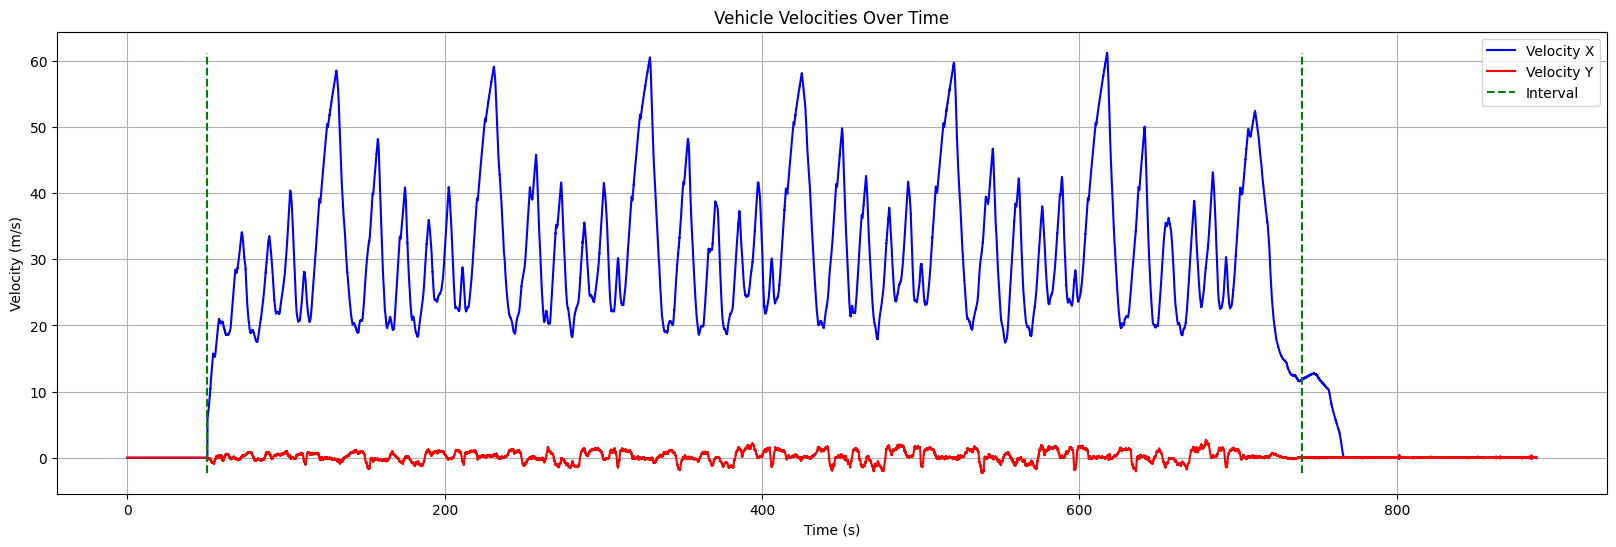

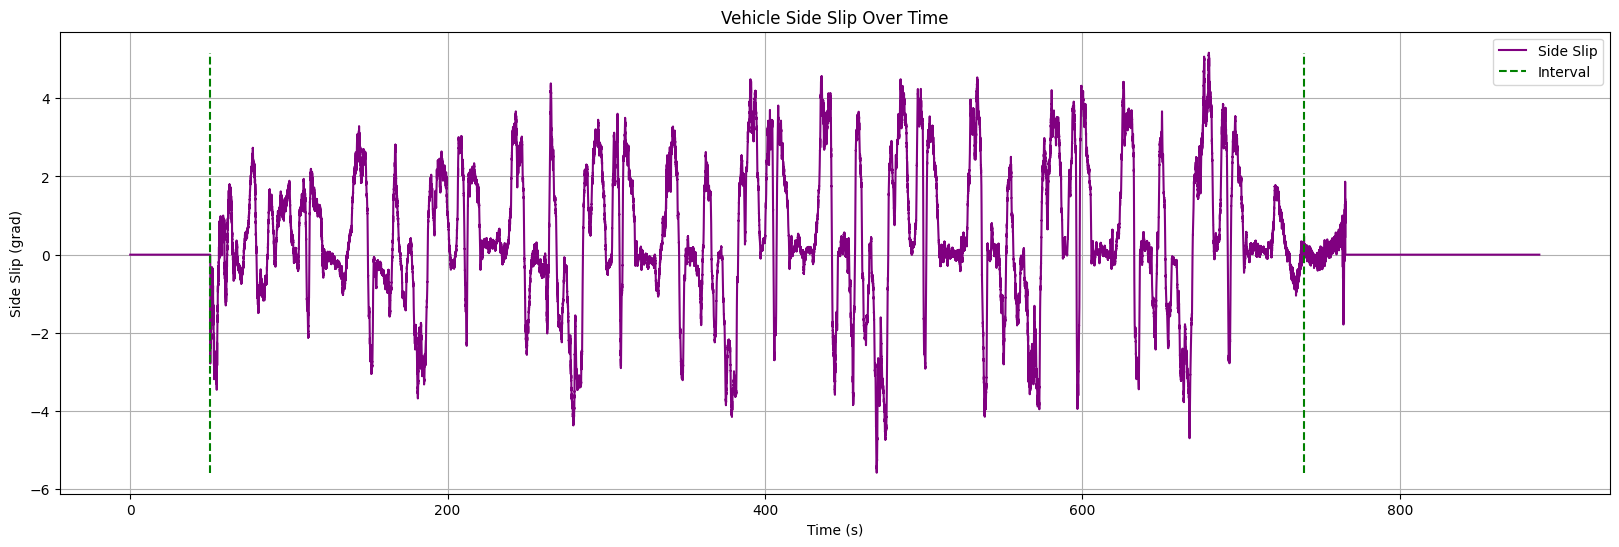

In [5]:
start_t=50
stop_t=start_t + 11.5*60
plot_data(test_data, start_t=start_t, stop_t=stop_t)

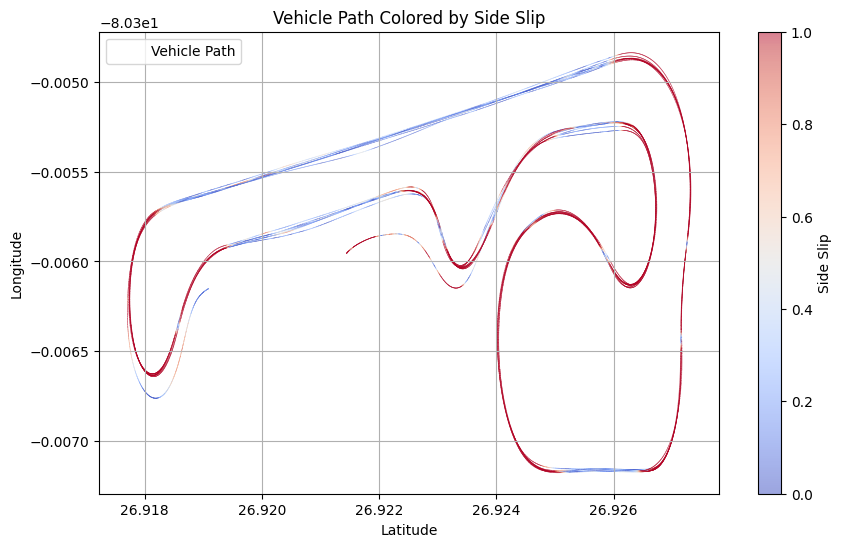

In [6]:
test_data = test_data[(test_data['time'] >= start_t) & (test_data['time'] <= stop_t)]

plot_vehicle_path(test_data)

In [7]:
save_to_file(test_data, 'processed_test_data.csv')

Data saved to processed_test_data.csv


# One Lap

___

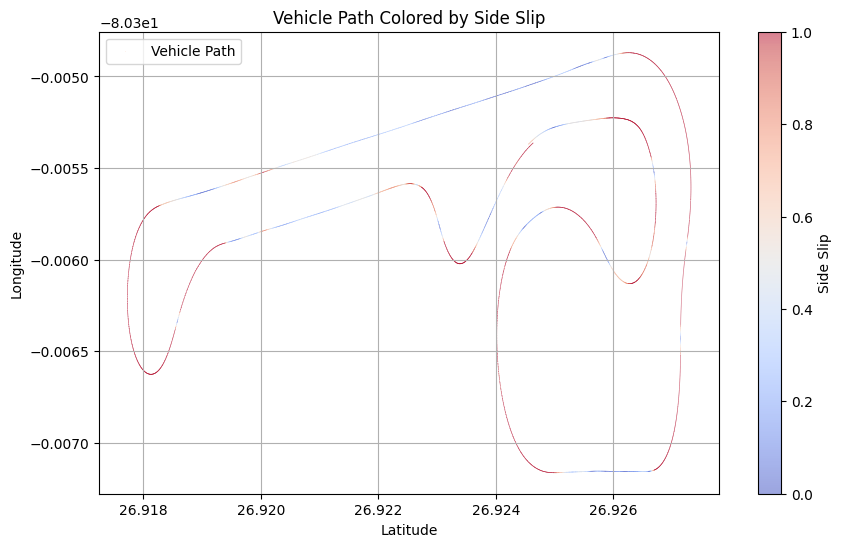

In [6]:
one_lap_data = test_data[(test_data['time'] >= 70) & (test_data['time'] <= 173)] #276
plot_vehicle_path(one_lap_data)

In [8]:
save_to_file(one_lap_data, 'processed_test_one_lap_data.csv')

Data saved to processed_test_one_lap_data.csv


# Training Data

The training data is obtained from the Revs Vehicle Dynamics Database.
The dataset corresponds to the 2013 Targa Sixty-Six event.

MAT File:
20130222_01_02_03_grandsport.mat

In [6]:

train_file_path = r"C:\Users\msbka\PINNS\Dataset\20130222_01_02_03_grandsport.mat"
train_data = mat_to_pandas(train_file_path, features)
# Display the first few rows of the test DataFrame
print(train_data.head())

    latitude  longitude  sideSlip      vxCG      vyCG      axCG      ayCG  \
0  26.920794 -80.306057       0.0 -0.008763  0.004499  0.215831  0.571743   
1  26.920794 -80.306057       0.0 -0.008364  0.012522  0.009553 -0.654905   
2  26.920794 -80.306057       0.0 -0.007207  0.019551 -0.088390 -0.241379   
3  26.920794 -80.306057       0.0 -0.009070 -0.000904  0.063293  0.049130   
4  26.920794 -80.306057       0.0 -0.008928 -0.009824 -0.000731 -0.062028   

    yawRate  time  
0 -0.064669  0.00  
1  0.041858  0.01  
2  0.076798  0.02  
3 -0.026415  0.03  
4  0.006813  0.04  


## Handle NaN values and interpolate missing entries

In [7]:

# Display the number of NaN values before preprocessing
print("NaN values before interpolation:\n")
print(train_data.isna().sum())

# Apply linear interpolation to fill missing values in all columns.
# The 'limit_direction' argument ensures interpolation occurs at the beginning
# and end of the dataset if needed.
train_data.interpolate(method="linear", limit_direction="both", inplace=True)

# Replace any remaining NaN values (if interpolation is not possible) with zeros.
train_data.fillna(0, inplace=True)

# Display the number of NaN values after preprocessing
print("\nNaN values after interpolation and filling:\n")
print(train_data.isna().sum())



NaN values before interpolation:

latitude     0
longitude    0
sideSlip     0
vxCG         0
vyCG         0
axCG         0
ayCG         0
yawRate      0
time         0
dtype: int64

NaN values after interpolation and filling:

latitude     0
longitude    0
sideSlip     0
vxCG         0
vyCG         0
axCG         0
ayCG         0
yawRate      0
time         0
dtype: int64


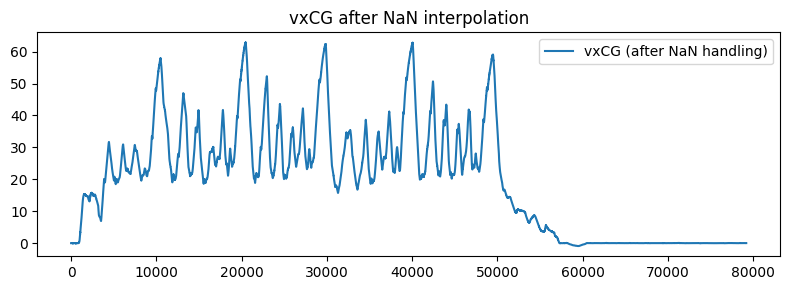

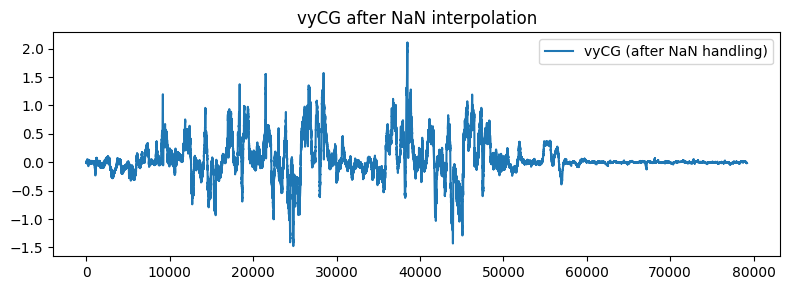

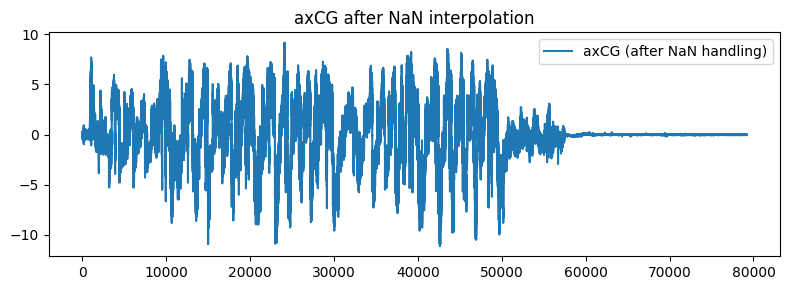

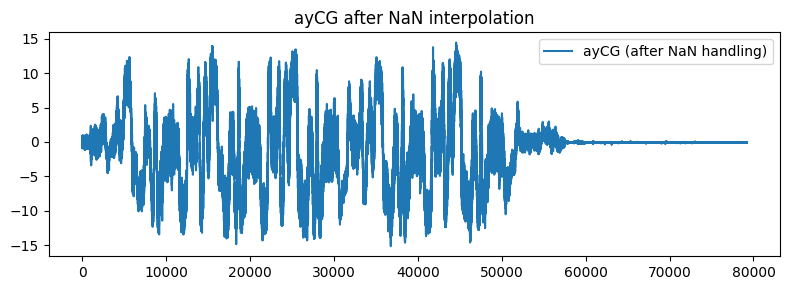

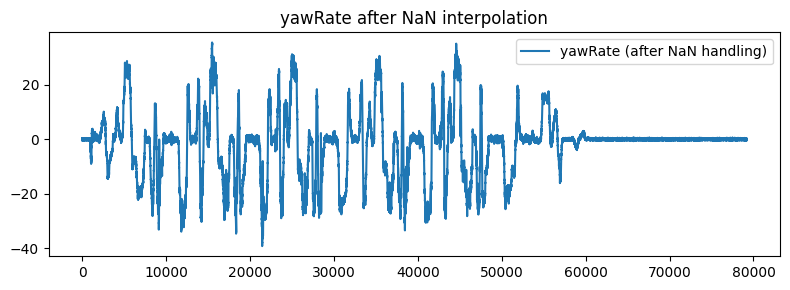

In [8]:

# Plotting After NAN Handling

cols_to_plot = ['vxCG', 'vyCG', 'axCG', 'ayCG', 'yawRate']
for col in cols_to_plot:
    plt.figure(figsize=(8, 3))
    plt.plot(train_data[col].values, label=f'{col} (after NaN handling)')
    plt.title(f'{col} after NaN interpolation')
    plt.legend()
    plt.tight_layout()
    plt.show()


## Signal Smoothing Using Savitzky–Golay Filter

To reduce measurement noise in the vehicle dynamics signals, a Savitzky–Golay filter is applied.

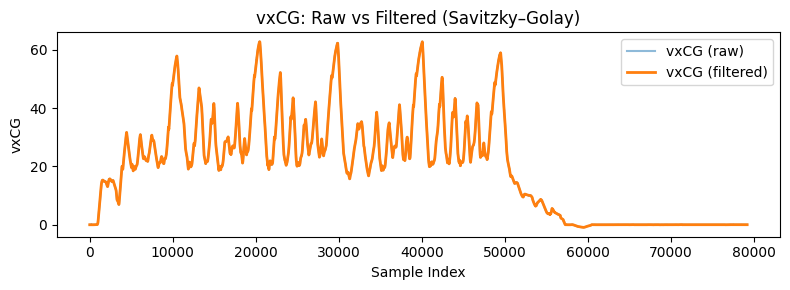

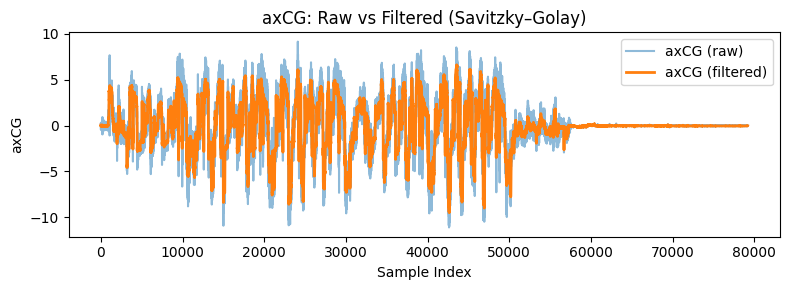

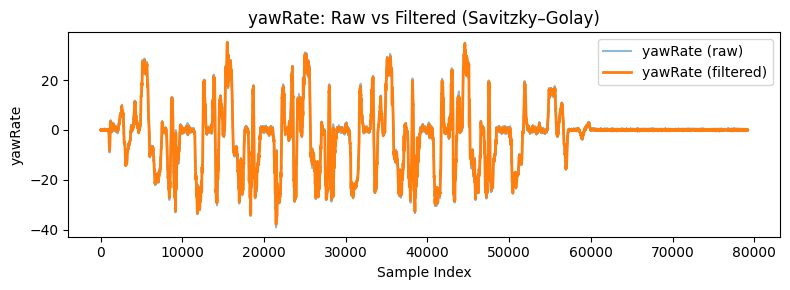

In [9]:
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt

def smooth_signal(sig, window=31, poly=2):
    """
    Apply Savitzky–Golay filtering to smooth a one-dimensional signal.

    Parameters
    ----------
    sig : array-like
        Input signal to be smoothed.
    window : int, optional
        Window length for the filter. Must be a positive odd integer.
        If the provided window is too large or even, it is adjusted automatically.
    poly : int, optional
        Polynomial order used by the filter.

    Returns
    -------
    ndarray
        Smoothed version of the input signal.
    """

    # Ensure the window size is valid relative to the signal length
    if window >= len(sig):
        window = len(sig) - 1 if len(sig) % 2 == 0 else len(sig)

    # Window length must be odd
    if window % 2 == 0:
        window += 1

    return savgol_filter(sig, window_length=window, polyorder=poly, mode='nearest')


# Core vehicle dynamics channels to smooth
cols_to_filter = ["vxCG", "vyCG", "axCG", "ayCG", "yawRate"]

# Apply smoothing and create new filtered columns
for col in cols_to_filter:
    train_data[col + "_filt"] = smooth_signal(
        train_data[col].values, window=31, poly=2
    )


# Plot comparison: raw vs filtered signals
for col in ["vxCG", "axCG", "yawRate"]:
    plt.figure(figsize=(8, 3))
    plt.plot(train_data[col].values, label=f"{col} (raw)", alpha=0.5)
    plt.plot(train_data[col + "_filt"].values, label=f"{col} (filtered)", linewidth=2)
    plt.title(f"{col}: Raw vs Filtered (Savitzky–Golay)")
    plt.xlabel("Sample Index")
    plt.ylabel(col)
    plt.legend()
    plt.tight_layout()
    plt.show()



In [10]:

# Train data After filtering
print(train_data.head())

    latitude  longitude  sideSlip      vxCG      vyCG      axCG      ayCG  \
0  26.920794 -80.306057       0.0 -0.008763  0.004499  0.215831  0.571743   
1  26.920794 -80.306057       0.0 -0.008364  0.012522  0.009553 -0.654905   
2  26.920794 -80.306057       0.0 -0.007207  0.019551 -0.088390 -0.241379   
3  26.920794 -80.306057       0.0 -0.009070 -0.000904  0.063293  0.049130   
4  26.920794 -80.306057       0.0 -0.008928 -0.009824 -0.000731 -0.062028   

    yawRate  time  vxCG_filt  vyCG_filt  axCG_filt  ayCG_filt  yawRate_filt  
0 -0.064669  0.00  -0.009400   0.002455   0.061933   0.224746     -0.000639  
1  0.041858  0.01  -0.009507   0.001817   0.048313   0.195024     -0.013570  
2  0.076798  0.02  -0.009565   0.001258   0.025589   0.133943      0.013570  
3 -0.026415  0.03  -0.009590   0.001107   0.006740   0.128307      0.005980  
4  0.006813  0.04  -0.009600   0.000440  -0.014667   0.068254      0.004340  



## Data preparation and DataLoader setup

Traindata Split into Train (80%) and validation (20%).

In [11]:

# The code below prepares one-step-ahead training pairs
# kinematic vehicle model and constructs PyTorch DataLoaders.

import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# ---------------------------------------------------------------------
# Build input (X_k) and target (X_{k+1}) arrays from filtered signals
# ---------------------------------------------------------------------
vx = train_data["vxCG_filt"].values
vy = train_data["vyCG_filt"].values
r  = train_data["yawRate_filt"].values
ax = train_data["axCG_filt"].values
ay = train_data["ayCG_filt"].values

# Input at time k:  [vx, vy, r, ax, ay]
# Target at time k+1: [vx_next, vy_next]
X = np.column_stack([vx[:-1], vy[:-1], r[:-1], ax[:-1], ay[:-1]])
Y = np.column_stack([vx[1:], vy[1:]])

print(f"Full dataset -> Inputs: {X.shape}, Targets: {Y.shape}")

# ---------------------------------------------------------------------
# Train/test split
# ---------------------------------------------------------------------
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, shuffle=True
)

print(f"Training samples: {len(X_train)} | Testing samples: {len(X_test)}")

# ---------------------------------------------------------------------
# Feature-wise scalers
# - Use MinMax for vx (non-negative, bounded) and StandardScaler for
#   the signals that can take positive and negative values.
# - Fit scalers on training data only to avoid data leakage.
# ---------------------------------------------------------------------
scaler_vx = MinMaxScaler(feature_range=(0.0, 1.0))
scaler_vy = StandardScaler()
scaler_r  = StandardScaler()
scaler_ax = StandardScaler()
scaler_ay = StandardScaler()
scaler_Y  = StandardScaler()  # targets: vx_next, vy_next

# Fit scalers to training partitions (column slices keep 2D shape)
scaler_vx.fit(X_train[:, [0]])
scaler_vy.fit(X_train[:, [1]])
scaler_r.fit(X_train[:, [2]])
scaler_ax.fit(X_train[:, [3]])
scaler_ay.fit(X_train[:, [4]])
scaler_Y.fit(Y_train)

# Transform train and test sets
X_train_scaled = np.column_stack([
    scaler_vx.transform(X_train[:, [0]]),
    scaler_vy.transform(X_train[:, [1]]),
    scaler_r.transform(X_train[:, [2]]),
    scaler_ax.transform(X_train[:, [3]]),
    scaler_ay.transform(X_train[:, [4]]),
])
X_test_scaled = np.column_stack([
    scaler_vx.transform(X_test[:, [0]]),
    scaler_vy.transform(X_test[:, [1]]),
    scaler_r.transform(X_test[:, [2]]),
    scaler_ax.transform(X_test[:, [3]]),
    scaler_ay.transform(X_test[:, [4]]),
])

Y_train_scaled = scaler_Y.transform(Y_train)
Y_test_scaled  = scaler_Y.transform(Y_test)

print("Scaling complete.")
print("Scaled X_train sample:\n", np.round(X_train_scaled[:3], 3))
print("Scaled Y_train sample:\n", np.round(Y_train_scaled[:3], 3))

# ---------------------------------------------------------------------
# Utility transform functions (useful at inference/evaluation time)
# ---------------------------------------------------------------------
def transform_X(X):
    """
    Scale raw input features to the model input space.

    Parameters
    ----------
    X : ndarray, shape (n_samples, 5)
        Raw inputs in order [vx, vy, r, ax, ay].

    Returns
    -------
    ndarray, shape (n_samples, 5)
        Scaled inputs using the feature-wise scalers fitted on training data.
    """
    return np.column_stack([
        scaler_vx.transform(X[:, [0]]),
        scaler_vy.transform(X[:, [1]]),
        scaler_r.transform(X[:, [2]]),
        scaler_ax.transform(X[:, [3]]),
        scaler_ay.transform(X[:, [4]]),
    ])


def inverse_transform_Y(Y_scaled):
    """
    Convert scaled model outputs back to physical units.

    Parameters
    ----------
    Y_scaled : ndarray or tensor-like, shape (n_samples, 2)
        Scaled outputs from the model.

    Returns
    -------
    ndarray, shape (n_samples, 2)
        Outputs in original physical units corresponding to [vx_next, vy_next].
    """
    return scaler_Y.inverse_transform(Y_scaled)

# ---------------------------------------------------------------------
# PyTorch Dataset and DataLoader
# ---------------------------------------------------------------------
class VehicleDataset(Dataset):
    """
    Simple Dataset for vehicle one-step-ahead training pairs.

    Each item is a tuple (X_scaled, Y_scaled) where:
      - X_scaled : torch.float32 tensor of shape (5,)
      - Y_scaled : torch.float32 tensor of shape (2,)
    """
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]


train_dataset = VehicleDataset(X_train_scaled, Y_train_scaled)
test_dataset  = VehicleDataset(X_test_scaled,  Y_test_scaled)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
Val_Data_loader  = DataLoader(test_dataset,  batch_size=128, shuffle=False)

print("Train/test split and scaled DataLoaders ready.")


Full dataset -> Inputs: (79199, 5), Targets: (79199, 2)
Training samples: 63359 | Testing samples: 15840
Scaling complete.
Scaled X_train sample:
 [[ 0.304 -0.323 -1.684  0.671 -1.314]
 [ 0.419  1.026 -0.868  1.267 -1.068]
 [ 0.594 -1.499  0.758  1.794  1.163]]
Scaled Y_train sample:
 [[-0.078 -0.32 ]
 [ 0.354  1.018]
 [ 1.016 -1.496]]
Train/test split and scaled DataLoaders ready.


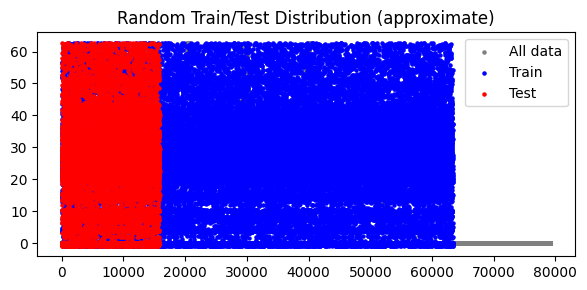

In [12]:
plt.figure(figsize=(6,3))
plt.scatter(range(len(vx)-1), vx[:-1], c='gray', s=5, label='All data')
plt.scatter(range(len(X_train)), X_train[:,0], c='blue', s=5, label='Train')
plt.scatter(range(len(X_test)), X_test[:,0], c='red', s=5, label='Test')
plt.title("Random Train/Test Distribution (approximate)")
plt.legend()
plt.tight_layout()
plt.show()

# External Test Dataset

For evaluating the trained PINN model, an independent dataset from the Revs Vehicle Dynamics Database is used.
This dataset corresponds to the 2014 Targa Sixty-Six event.

MAT File: 20140221_04_01_03_250lm.mat

it is denoted as Car B

In [36]:
test_file_path = r"C:\Users\msbka\PINNS\Dataset\20140221_04_01_03_250lm.mat"
test_data_carB = mat_to_pandas(test_file_path, features)
# Display the first few rows of the test DataFrame
print(test_data_carB.head())



   latitude  longitude  sideSlip  vxCG  vyCG      axCG      ayCG   yawRate  \
0       NaN        NaN       0.0   0.0   0.0  0.054183  0.042289  0.037534   
1       NaN        NaN       0.0   0.0   0.0  0.147014 -0.058505  0.388898   
2       NaN        NaN       0.0   0.0   0.0 -0.291975  0.730036 -0.142416   
3       NaN        NaN       0.0   0.0   0.0  0.111661 -0.086679  0.120025   
4       NaN        NaN       0.0   0.0   0.0  0.001944  0.053631  0.184540   

   time  
0  0.00  
1  0.01  
2  0.02  
3  0.03  
4  0.04  


In [37]:

# Load  car (Car B) dataset

vx_b = test_data_carB['vxCG'].values
vy_b = test_data_carB['vyCG'].values
r_b  = test_data_carB['yawRate'].values
ax_b = test_data_carB['axCG'].values
ay_b = test_data_carB['ayCG'].values

# Prepare input/output just like before
X_B = np.column_stack([vx_b[:-1], vy_b[:-1], r_b[:-1], ax_b[:-1], ay_b[:-1]])
Y_B = np.column_stack([vx_b[1:], vy_b[1:]])

print(f"External dataset (Car B) -> Inputs: {X_B.shape}, Targets: {Y_B.shape}")

External dataset (Car B) -> Inputs: (88799, 5), Targets: (88799, 2)


In [38]:
# Scale Car B using scalers from Car A
X_B_scaled = np.column_stack([
    scaler_vx.transform(X_B[:, [0]]),
    scaler_vy.transform(X_B[:, [1]]),
    scaler_r.transform(X_B[:, [2]]),
    scaler_ax.transform(X_B[:, [3]]),
    scaler_ay.transform(X_B[:, [4]]),
])
Y_B_scaled = scaler_Y.transform(Y_B)

# Create PyTorch dataset and DataLoader
test_dataset_carB = VehicleDataset(X_B_scaled, Y_B_scaled)
test_loader_carB  = DataLoader(test_dataset_carB, batch_size=128, shuffle=False)

print(" External Car B DataLoader ready.")


 External Car B DataLoader ready.


# RMSE LOSS FUNCTION

In [39]:
import torch.nn as nn

class RMSELoss(nn.Module):
    def __init__(self, eps=1e-8):
        super().__init__()
        self.mse = nn.MSELoss()
        self.eps = eps

    def forward(self, y_pred, y_true):
        return torch.sqrt(self.mse(y_pred, y_true) + self.eps)

criterion = RMSELoss()


# Baseline Neural Network Model

This baseline model is a purely data-driven feed-forward neural network trained to predict one-step-ahead vehicle states.


**Model Configuration**

Activation Function: ReLU

Number of Epochs: 50

Loss Function: RMSE (Root Mean Squared Error)`
```



VehicleNN(
  (net): Sequential(
    (0): Linear(in_features=5, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=2, bias=True)
  )
)
Epoch [1/50] | Train Loss: 0.134820 | Test Loss: 0.025928
Epoch [2/50] | Train Loss: 0.021509 | Test Loss: 0.020052
Epoch [3/50] | Train Loss: 0.017293 | Test Loss: 0.020509
Epoch [4/50] | Train Loss: 0.015232 | Test Loss: 0.013509
Epoch [5/50] | Train Loss: 0.013624 | Test Loss: 0.012159
Epoch [6/50] | Train Loss: 0.012800 | Test Loss: 0.013221
Epoch [7/50] | Train Loss: 0.012535 | Test Loss: 0.011289
Epoch [8/50] | Train Loss: 0.011082 | Test Loss: 0.012387
Epoch [9/50] | Train Loss: 0.011717 | Test Loss: 0.009059
Epoch [10/50] | Train Loss: 0.010575 | Test Loss: 0.010271
Epoch [11/50] | Train Loss: 0.010193 | Test Loss: 0.011564
Epoch [12/50] | Train Loss: 0.010499 | Test Loss: 0.011674
Epoch [13/50] | Train Loss: 0.009732 | Test Loss: 0.0

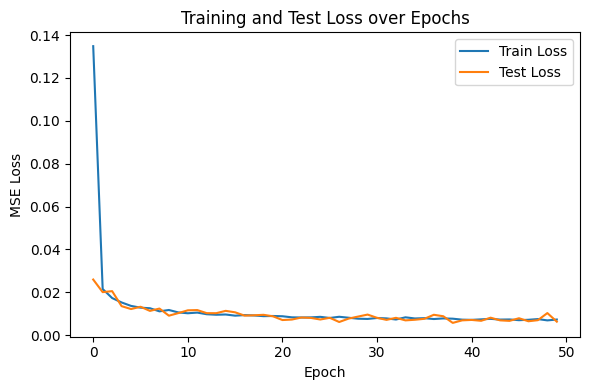

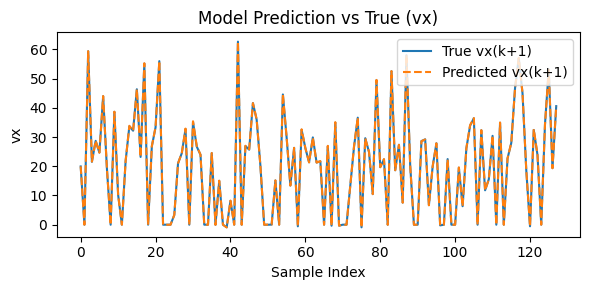

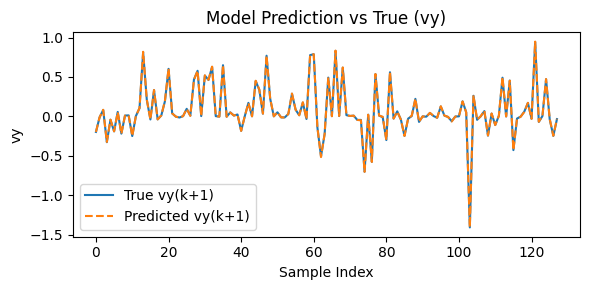

In [17]:
# Baseline data-driven neural network model
# The code below defines a simple feed-forward neural network, 
# trains it to predict one-step-ahead vehicle states, 
# and visualizes prediction performance on the scaled and real-unit test data.

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# Neural Network Architecture
# ---------------------------------------------------------------------
class VehicleNN(nn.Module):
    """
    Feed-forward neural network for one-step-ahead vehicle state prediction.

    Parameters
    ----------
    input_dim : int
        Number of input features per time step.
    hidden_dim : int
        Number of neurons in the hidden layers.
    output_dim : int
        Dimension of the output vector (vx_{k+1}, vy_{k+1}).
    """
    def __init__(self, input_dim=5, hidden_dim=64, output_dim=2):
        super(VehicleNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        """Forward pass through the network."""
        return self.net(x)


# Instantiate model
model = VehicleNN()
print(model)

# ---------------------------------------------------------------------
# Loss function and optimizer
# ---------------------------------------------------------------------
criterion = RMSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# ---------------------------------------------------------------------
# Training loop
# ---------------------------------------------------------------------
num_epochs = 50
train_losses = []
test_losses = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    # Training step
    for X_batch, Y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, Y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Evaluation step
    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for X_batch, Y_batch in Val_Data_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, Y_batch)
            test_loss += loss.item()

    avg_test_loss = test_loss / len(Val_Data_loader)
    test_losses.append(avg_test_loss)

    print(f"Epoch [{epoch + 1}/{num_epochs}] | "
          f"Train Loss: {avg_train_loss:.6f} | Test Loss: {avg_test_loss:.6f}")

print("Training complete.")

# ---------------------------------------------------------------------
# Plot training and test loss curves
# ---------------------------------------------------------------------
plt.figure(figsize=(6, 4))
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.title("Training and Test Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# Evaluate model on a batch of test samples (real unit comparison)
# ---------------------------------------------------------------------
model.eval()
with torch.no_grad():
    X_test_sample, Y_test_sample = next(iter(Val_Data_loader))
    Y_pred_scaled = model(X_test_sample).cpu().numpy()
    Y_true_scaled = Y_test_sample.cpu().numpy()

# Inverse scaling to obtain real physical units
Y_pred = scaler_Y.inverse_transform(Y_pred_scaled)
Y_true = scaler_Y.inverse_transform(Y_true_scaled)

# ---------------------------------------------------------------------
# Plot vx prediction comparison
# ---------------------------------------------------------------------
plt.figure(figsize=(6, 3))
plt.plot(Y_true[:200, 0], label="True vx(k+1)")
plt.plot(Y_pred[:200, 0], label="Predicted vx(k+1)", linestyle="--")
plt.title("Model Prediction vs True (vx)")
plt.xlabel("Sample Index")
plt.ylabel("vx")
plt.legend()
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# Plot vy prediction comparison
# ---------------------------------------------------------------------
plt.figure(figsize=(6, 3))
plt.plot(Y_true[:200, 1], label="True vy(k+1)")
plt.plot(Y_pred[:200, 1], label="Predicted vy(k+1)", linestyle="--")
plt.title("Model Prediction vs True (vy)")
plt.xlabel("Sample Index")
plt.ylabel("vy")
plt.legend()
plt.tight_layout()
plt.show()


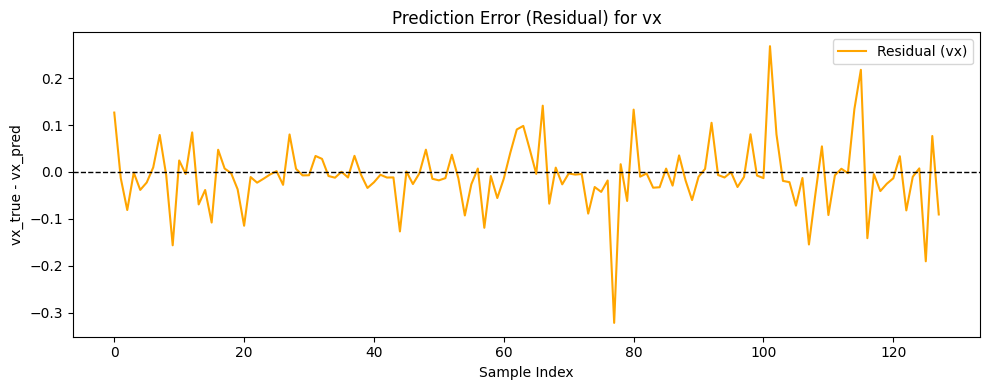

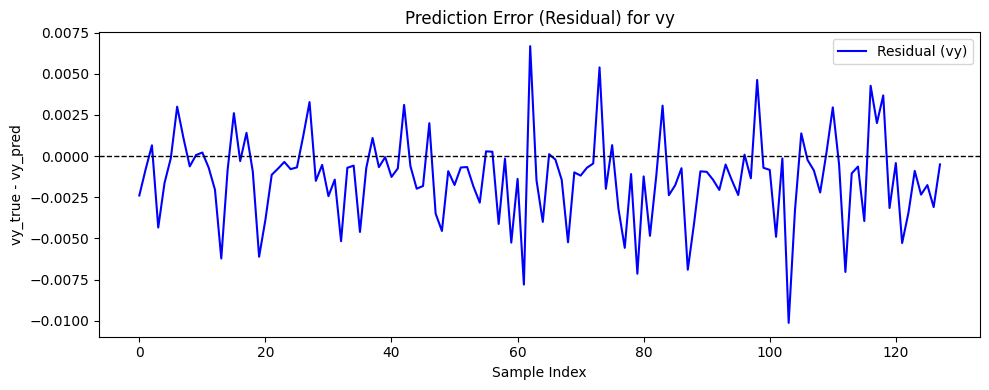

vx Residuals → Mean: -0.008491, Std: 0.070148, RMSE: 0.070660
vy Residuals → Mean: -0.001295, Std: 0.002630, RMSE: 0.002931


In [20]:

import matplotlib.pyplot as plt
import numpy as np

# Compute residuals (difference between true and predicted)
residual_vx = Y_true[:, 0] - Y_pred[:, 0]
residual_vy = Y_true[:, 1] - Y_pred[:, 1]

# Plot residuals over sample index
plt.figure(figsize=(10, 4))
plt.plot(residual_vx, label='Residual (vx)', color='orange')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title("Prediction Error (Residual) for vx")
plt.xlabel("Sample Index")
plt.ylabel("vx_true - vx_pred")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(residual_vy, label='Residual (vy)', color='blue')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title("Prediction Error (Residual) for vy")
plt.xlabel("Sample Index")
plt.ylabel("vy_true - vy_pred")
plt.legend()
plt.tight_layout()
plt.show()


def residual_stats(name, residuals):
    mean_err = np.mean(residuals)
    std_err = np.std(residuals)
    rmse = np.sqrt(np.mean(residuals**2))
    print(f"{name} Residuals → Mean: {mean_err:.6f}, Std: {std_err:.6f}, RMSE: {rmse:.6f}")

residual_stats("vx", residual_vx)
residual_stats("vy", residual_vy)


# Kinematic Vehicle Model (KVM) Solver

Computes the next-step velocities using a first-order kinematic update.


In [18]:
# Kinematic Vehicle Model (KVM) Solver
# Computes the next-step velocities using a first-order kinematic update.

import torch

def physics_next_state(vx, vy, r, ax, ay, dt=0.01):
    """
    Compute the next-step longitudinal and lateral velocities using the
    discrete-time Kinematic Vehicle Model (KVM).

    Parameters
    ----------
    vx : tensor
        Longitudinal velocity at time step k.
    vy : tensor
        Lateral velocity at time step k.
    r : tensor
        Yaw rate at time step k.
    ax : tensor
        Longitudinal acceleration at time step k.
    ay : tensor
        Lateral acceleration at time step k.
    dt : float, optional
        Sampling time step for integration.

    Returns
    -------
    vx_next : tensor
        Predicted longitudinal velocity at time step k+1.
    vy_next : tensor
        Predicted lateral velocity at time step k+1.
    """

    # Kinematic update equations
    vx_next = vx + dt * (ax - r * vy)
    vy_next = vy + dt * (ay + r * vx)

    return vx_next, vy_next


# Quick sanity check
vx0 = torch.tensor([20.0])
vy0 = torch.tensor([0.5])
r0  = torch.tensor([0.1])
ax0 = torch.tensor([2.0])
ay0 = torch.tensor([-0.5])

vx_next, vy_next = physics_next_state(vx0, vy0, r0, ax0, ay0)
print(f"vx_next: {vx_next.item():.3f}, vy_next: {vy_next.item():.3f}")


vx_next: 20.020, vy_next: 0.515


# Latin Hypercube Sampling of Initial Conditions



In [19]:
from scipy.stats import qmc
import numpy as np

def generate_initial_conditions(N_phys=5):
    """
    Generate physically meaningful initial conditions for physics-based
    residual computation using Latin Hypercube Sampling (LHS).

    Variables sampled:
        vx, vy, r, ax, ay

    Parameters
    ----------
    N_phys : int
        Number of physics sample points to generate.

    Returns
    -------
    ndarray, shape (N_phys, 5)
        Sampled initial conditions.
    """

    sampler = qmc.LatinHypercube(d=5)
    sample = sampler.random(n=N_phys)

    # physical bounds for variables [vx, vy, r, ax, ay]
    lower_bounds = [0, -8, -20, -40, -50]
    upper_bounds = [70, 8, 20, 40, 50]

    initial_conditions = qmc.scale(sample, lower_bounds, upper_bounds)
    return initial_conditions


# Example generation test
X_phys_small = generate_initial_conditions(N_phys=4)
print("Random Physics Points Generated (small test set)")
print("Shape:", X_phys_small.shape)
print("Generated Points:\n", np.round(X_phys_small, 3))


Random Physics Points Generated (small test set)
Shape: (4, 5)
Generated Points:
 [[ 24.875  -7.431  -8.434  13.572  35.338]
 [ 45.998   0.778   4.108  26.562  10.343]
 [ 55.467  -0.108  19.841 -33.624  -9.516]
 [ 13.786   5.6   -19.482 -12.386 -42.619]]


In [20]:

#  SCALE RANDOM POINTS

N_phys = 4  # or 5 for now (start small for testing)
X_phys_real = generate_initial_conditions(N_phys)

print(" Random Physics Points (Real Units):")
print(np.round(X_phys_real, 3))

# --- Scale them using the same feature-wise scalers ---
X_phys_scaled = transform_X(X_phys_real)

print("\n Random Physics Points (Scaled Units):")
print(np.round(X_phys_scaled, 3))

# --- Sanity check ---
print(f"\nShape of X_phys_real:   {X_phys_real.shape}")
print(f"Shape of X_phys_scaled: {X_phys_scaled.shape}")




 Random Physics Points (Real Units):
[[ 38.163  -3.768  15.58  -23.623 -49.066]
 [ 18.091   5.184   6.613 -14.045  11.807]
 [ 61.022  -7.16   -6.482  17.27   47.79 ]
 [ 14.127   2.741 -19.813  29.536 -14.354]]

 Random Physics Points (Scaled Units):
[[  0.613 -12.401   1.517  -9.314 -10.408]
 [  0.298  16.628   0.748  -5.544   2.779]
 [  0.972 -23.399  -0.375   6.781  10.573]
 [  0.236   8.705  -1.518  11.608  -2.888]]

Shape of X_phys_real:   (4, 5)
Shape of X_phys_scaled: (4, 5)


# Compute Physics Loss




In [ ]:

# import torch
# import numpy as np
# import matplotlib.pyplot as plt

# def compute_physics_loss(model, X_phys_real, X_phys_scaled, dt=0.01, debug=False):
#     """
#     Parameters
#     ----------
#     model : torch.nn.Module
#         Trained neural network that maps scaled inputs -> scaled outputs.
#     X_phys_real : np.ndarray, shape (N_phys, 5)
#         Collocation points in real physical units arranged as columns:
#         [vx, vy, r, ax, ay].
#     X_phys_scaled : np.ndarray, shape (N_phys, 5)
#         The same collocation points transformed into the model's input (scaled) space.
#     dt : float, optional
#         Time-step for the discrete KVM (default 0.01).
#     device : torch.device or None, optional
#         Device to run inference on. If None, uses CPU.
#     debug : bool, optional
#         If True, print intermediate arrays for debugging.

#     Returns
#     -------
#     fx : np.ndarray, shape (N_phys,)
#         Residuals for vx: (NN_predicted_vx - physics_vx_next).
#     fy : np.ndarray, shape (N_phys,)
#         Residuals for vy: (NN_predicted_vy - physics_vy_next).
#     L_phys : float
#         Root Mean squared physics loss: sqrt (mean(fx**2 + fy**2)).
    

#     """

#     #  Convert to tensors
#     X_phys_scaled_t = torch.tensor(X_phys_scaled, dtype=torch.float32)
#     X_phys_real_t   = torch.tensor(X_phys_real, dtype=torch.float32)

#     # NN prediction (scaled → real physical units)
#     with torch.no_grad():
#         Y_pred_scaled = model(X_phys_scaled_t).numpy()
#     # inverse transform from scaled to real units (m/s)
#     Y_pred_real = inverse_transform_Y(Y_pred_scaled)

#     # Physics next state (using KVM solver) 
#     vx, vy, r, ax, ay = [X_phys_real_t[:, i] for i in range(5)]
#     vx_next_phys, vy_next_phys = physics_next_state(vx, vy, r, ax, ay, dt)
#     Y_phys_next = torch.stack([vx_next_phys, vy_next_phys], dim=1).numpy()

#     # ---  Compute residuals (NN - Physics) ---
#     fx = Y_pred_real[:, 0] - Y_phys_next[:, 0]  # vx residual
#     fy = Y_pred_real[:, 1] - Y_phys_next[:, 1]  # vy residual

#     # ---  Physics loss (Mean Squared Error) ---
#     L_phys = np.sqrt(np.mean(fx**2 + fy**2))

#     # debug output ---
#     if debug:
#         print("\n Debug Info:")
#         print("NN predictions (real units):\n", np.round(Y_pred_real, 3))
#         print("Physics next state (real units):\n", np.round(Y_phys_next, 3))
#         print("Residual fx (vx diff):", np.round(fx, 3))
#         print("Residual fy (vy diff):", np.round(fy, 3))

#     return fx, fy, L_phys


# # ---- Run it ----
# fx, fy, L_phys = compute_physics_loss(model, X_phys_real, X_phys_scaled, dt=0.01, debug=True)
# print(f"\n Physics-only loss computed (N={len(X_phys_real)}): {L_phys:.6f}")



 Debug Info:
NN predictions (real units):
 [[68.54   4.028]
 [49.127  1.629]
 [83.119 -6.955]
 [55.954 -1.014]]
Physics next state (real units):
 [[37.311 11.217]
 [ 9.433  1.842]
 [65.727 -5.719]
 [31.564 -6.488]]
Residual fx (vx diff): [31.229 39.695 17.393 24.391]
Residual fy (vy diff): [-7.188 -0.213 -1.235  5.474]

 Physics-only loss computed (N=4): 29.713369


In [34]:
# # ============================================================
# # 🔹 STEP: PLOT PHYSICS RESIDUALS
# # ============================================================
# plt.figure(figsize=(10, 4))
# plt.plot(fx, 'o-', label='Residual (vx)', color='orange')
# plt.plot(fy, 's-', label='Residual (vy)', color='blue')
# plt.axhline(0, color='black', linestyle='--', linewidth=1)
# plt.title(f"Physics Residuals (N={len(fx)} random points)")
# plt.xlabel("Sample Index")
# plt.ylabel("Residual (Predicted - Physics) [m/s]")
# plt.legend()
# plt.tight_layout()
# plt.show()

# # --- Print summary stats ---
# def residual_stats(name, residuals):
#     mean_err = np.mean(residuals)
#     std_err  = np.std(residuals)
#     rmse     = np.sqrt(np.mean(residuals**2))
#     print(f"{name} Residuals → Mean: {mean_err:.6f}, Std: {std_err:.6f}, RMSE: {rmse:.6f}")

# residual_stats("vx", fx)
# residual_stats("vy", fy)


In [21]:
# ---------------------------------------------------------------------
# Setup: Device selection and Hyperparameter configuration
# ---------------------------------------------------------------------

import torch
import numpy as np
import math
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# Device setup (GPU if available, otherwise CPU)
# ---------------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print("Using device:", device)


# ---------------------------------------------------------------------
# Hyperparameter configuration function
# Returns a dictionary containing all key training parameters
# ---------------------------------------------------------------------
def get_hyperparams(num_epochs=50,
                    w_data=1.0,
                    w_phys_init=0.1,
                    decay_rate=0.03,
                    N_phys=64,
                    dt=0.01,
                    lr=1e-3):
    """
    Returns a dictionary of hyperparameters used for PINN training.

    Parameters
    ----------
    num_epochs : int
        Number of training epochs.
    w_data : float
        Weight for data loss.
    w_phys_init : float
        Initial weight for physics loss.
    decay_rate : float
        Exponential decay rate for physics loss weight.
    N_phys : int
        Number of physics-based samples per batch.
    dt : float
        Time step for physics next-state computation.
    lr : float
        Learning rate for optimizer.

    Returns
    -------
    dict
        Hyperparameter configuration.
    """
    return {
        "num_epochs": num_epochs,
        "w_data": w_data,
        "w_phys_init": w_phys_init,
        "decay_rate": decay_rate,
        "N_phys": N_phys,
        "dt": dt,
        "lr": lr,
    }


print("Hyperparameter manager initialized.")


Using device: cpu
Hyperparameter manager initialized.


# Compute Physics Loss

## The function does the following:

1. Converts the provided collocation points to torch tensors.
2. Uses the model to predict the next-step outputs for the scaled inputs.
3. Converts model outputs from the scaled space back to real physical units using `inverse_transform_Y`
4. Computes the physics-predicted next state using the Kinematic Vehicle Model (KVM).
5. Returns the residuals (fx, fy) in real units and the Root mean-squared physics loss L_phys.

In [22]:

def compute_physics_loss_torch(model, N_phys, dt, device):

    """
    Computes the Physics-Informed Loss using Root Mean Squared Error (RMSE).

    Compares the model's predicted next state (real units) with the next state 
    computed by an analytical kinematic model.

    Args:
        model: The PyTorch neural network model.
        N_phys: The number of random samples (batch size).
        dt: The time step (delta time) used in the kinematic model.
        device: The device ('cuda' or 'cpu') where tensors should be placed.

    Returns:
        A scalar torch.Tensor representing the Root Mean Squared Error (RMSE) physics loss.
    """
   
   # 1. Generate Input Samples and Transform to Tensors
    # Generate random samples (real + scaled)
    X_phys_real = generate_initial_conditions(N_phys)
    X_phys_scaled = transform_X(X_phys_real)

    # Convert to PyTorch tensors and move to the specified device
    X_phys_scaled_t = torch.tensor(X_phys_scaled, dtype=torch.float32, device=device)
    X_phys_real_t   = torch.tensor(X_phys_real, dtype=torch.float32, device=device)

    # 2. Neural Network Prediction
    # NN prediction on scaled input
    Y_pred_scaled = model(X_phys_scaled_t)

   # 3. Inverse Scaling of Prediction
    # Convert scaled prediction back to real physical units
    # Assumes scaler_Y.scale_ and scaler_Y.mean_ are numpy arrays/lists
    scale_tensor = torch.tensor(scaler_Y.scale_, dtype=torch.float32, device=device)
    mean_tensor  = torch.tensor(scaler_Y.mean_, dtype=torch.float32, device=device)
    Y_pred_real  = Y_pred_scaled * scale_tensor + mean_tensor

    # 4. Compute Next State using Analytical Physics Model
    # the input X_phys_real_t is [vx, vy, r, ax, ay, ...]
    vx, vy, r, ax, ay = [X_phys_real_t[:, i] for i in range(5)]

    # Compute the next state (e.g., next velocity) using the analytical kinematic function
    vx_next_phys, vy_next_phys = physics_next_state(vx, vy, r, ax, ay, dt)

    # Stack the physical next-state variables into a single tensor [N_phys, 2]
    # The shape should match the output of the NN (Y_pred_real)
    Y_phys_next = torch.stack([vx_next_phys, vy_next_phys], dim=1)

   # 5. Compute Physics Loss (Root Mean Squared Error)
    loss_phys = torch.sqrt(torch.mean((Y_pred_real - Y_phys_next)**2))
    return loss_phys


## Model Training 





In [23]:

import math

def train_pinn(model, params, train_loader, device):

    """
    Train a Physics-Informed Neural Network (PINN) with combined data and physics loss.

    Parameters
    ----------
    model : torch.nn.Module
        Neural network model to be trained.
    params : dict
        Dictionary of hyperparameters with the following keys:
            - "lr"         : float, learning rate for Adam optimizer
            - "num_epochs" : int, number of training epochs
            - "w_data"     : float, weight for the data loss term
            - "w_phys_init": float, initial weight for the physics loss term
            - "decay_rate" : float, exponential decay rate for the physics weight
            - "N_phys"     : int, number of physics collocation points per step
            - "dt"         : float, time step used in the KVM model
    train_loader : torch.utils.data.DataLoader
        DataLoader that yields (X_batch, Y_batch) pairs for training.
    device : torch.device
        Device on which to run the training (e.g. torch.device("cuda") or "cpu").

    Returns
    -------
    data_losses : list of float
        Epoch-wise mean data loss values.
    phys_losses : list of float
        Epoch-wise mean physics loss values.
    total_losses : list of float
        Epoch-wise mean total (weighted) loss values.
    """
   
# 1. Setup and Initialization

    # Move model to the selected device
    model = model.to(device)

     # Optimizer and loss function for the data term
    optimizer = torch.optim.Adam(model.parameters(), lr=params["lr"])
    criterion = RMSELoss()


  # Unpack training hyperparameters
    num_epochs = params["num_epochs"]
    w_data = params["w_data"]
    w_phys_init = params["w_phys_init"]
    decay_rate = params["decay_rate"]
    N_phys = params["N_phys"]
    dt = params["dt"]

     # Lists to store epoch-wise losses
    data_losses, phys_losses, total_losses = [], [], []

# 2. Main Training Loop

    for epoch in range(num_epochs):
        model.train()
        running_data_loss = 0.0
        running_phys_loss = 0.0
        running_total_loss = 0.0

        # Exponential decay for physics weight
        w_phys = w_phys_init * math.exp(-decay_rate * epoch)

        # Iterate over mini-batches
        for X_batch, Y_batch in train_loader:
            X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)

            # Reset gradients
            optimizer.zero_grad()

            # -----------------------------
            # Data loss term
            # -----------------------------
            Y_pred = model(X_batch)
            loss_data = criterion(Y_pred, Y_batch)

           # -----------------------------
            # Physics loss term
            # -----------------------------

            loss_phys = compute_physics_loss_torch(model, N_phys, dt, device)

             # -----------------------------
            # Total combined loss
            # -----------------------------

            loss_total = w_data * loss_data + w_phys * loss_phys

            # Backpropagation and optimizer step
            loss_total.backward()
            optimizer.step()


             # Accumulate batch losses (for epoch averages)
            running_data_loss += loss_data.item()
            running_phys_loss += loss_phys.item()
            running_total_loss += loss_total.item()


# 3. Epoch Summary and Logging

         # Mean losses over all batches in this epoch
        avg_data_loss  = running_data_loss / len(train_loader)
        avg_phys_loss  = running_phys_loss / len(train_loader)
        avg_total_loss = running_total_loss / len(train_loader)

        data_losses.append(avg_data_loss)
        phys_losses.append(avg_phys_loss)
        total_losses.append(avg_total_loss)

         # Training progress summary

        print(f"Epoch [{epoch+1:02d}/{num_epochs}] | "
              f"Data: {avg_data_loss:.6f} | "
              f"Physics: {avg_phys_loss:.6f} | "
              f"Total: {avg_total_loss:.6f} | "
              f"w_phys={w_phys:.4f} | N_phys={N_phys}")

    print(" Training complete.")
    return data_losses, phys_losses, total_losses



## Generate Initial Conditions For Test Data 

This function generates random physics samples specifically for External dataset (denoted as Car B), based on its actual dynamic range

In [24]:
import numpy as np

def generate_initial_conditions_carB(N_phys):
    """
    Generate N_phys random physical samples (x_k, u_k)
    for Car B domain using its data range.
    
    Returns: numpy array shape (N_phys, 5)
             [vx, vy, r, ax, ay]
    """
   
    # Compute realistic min and max
    bounds = {
        'vx': (np.min(vx_b), np.max(vx_b)),
        'vy': (np.min(vy_b), np.max(vy_b)),
        'r':  (np.min(r_b),  np.max(r_b)),
        'ax': (np.min(ax_b), np.max(ax_b)),
        'ay': (np.min(ay_b), np.max(ay_b)),
    }

    # Uniform sampling within Car B’s physical range
    vx_rand = np.random.uniform(*bounds['vx'], size=N_phys)
    vy_rand = np.random.uniform(*bounds['vy'], size=N_phys)
    r_rand  = np.random.uniform(*bounds['r'],  size=N_phys)
    ax_rand = np.random.uniform(*bounds['ax'], size=N_phys)
    ay_rand = np.random.uniform(*bounds['ay'], size=N_phys)

    
    X_phys_real = np.column_stack([vx_rand, vy_rand, r_rand, ax_rand, ay_rand])
    
    return X_phys_real


## Model Evaluation Using Test data

In [32]:
import torch
import torch.nn.functional as F
import numpy as np
import math

def evaluate_pinn_on_test(model, test_loader, device, dt=0.01, N_phys=128,
                          w_data=0.1, w_phys_init=0.1,epoch_idx=None,decay_rate=0):
    """
    Evaluate the trained PINN model on Car B (test data).
    Computes:
      - Data loss (RMSE) between NN predictions and measured next-state.
      - Physics loss (RMSE) between NN predictions and KVM-predicted next-state.
      - Total loss:  w_data * L_data + w_phys * L_phys
    """

    if epoch_idx is None:
        epoch_idx = num_epochs - 1

        # Physics weight with exponential decay
    #w_phys = w_phys_init * math.exp(-decay_rate * epoch_idx)
    w_phys = w_phys_init


    model.eval()
    total_data_loss, total_phys_loss = 0.0, 0.0
    n_batches = 0

    with torch.no_grad():
        for Xb, Yb in test_loader:
            Xb, Yb = Xb.to(device), Yb.to(device)

            # -------------------------------------------------------------
            # Data loss (RMSE) on samples
            # -------------------------------------------------------------

            Y_pred = model(Xb)
            loss_data = F.mse_loss(Y_pred, Yb)

             # -------------------------------------------------------------
            # Physics loss (RMSE) using KVM on synthetic collocation points
            
            # -------------------------------------------------------------

            # --- Generate random samples (from range) for physics consistency ---
            if test_loader == test_loader_carB:
              X_phys_real = generate_initial_conditions_carB(N_phys)
              
            else:
               X_phys_real = generate_initial_conditions(N_phys)
               

            X_phys_scaled = transform_X(X_phys_real)
            X_phys_scaled_t = torch.tensor(X_phys_scaled, dtype=torch.float32, device=device)

             # NN prediction for physics inputs (scaled → real units)
            Y_pred_phys_scaled = model(X_phys_scaled_t)
            Y_pred_phys_real = scaler_Y.inverse_transform(Y_pred_phys_scaled.cpu().numpy())
            Y_pred_phys_real_t = torch.tensor(Y_pred_phys_real, dtype=torch.float32, device=device)

            # --- Compute next state using KVM model ---
            X_phys_real_t = torch.tensor(X_phys_real, dtype=torch.float32, device=device)
            vx, vy, r, ax, ay = [X_phys_real_t[:, i] for i in range(5)]
            vx_next_phys, vy_next_phys = physics_next_state(vx, vy, r, ax, ay, dt)
            Y_phys_next = torch.stack([vx_next_phys, vy_next_phys], dim=1)

            # --- Physics loss (RMSE) ---
            loss_phys = torch.sqrt((F.mse_loss(Y_pred_phys_real_t, Y_phys_next)) + 1e-8)
            
             # Accumulate losses
            total_data_loss += loss_data.item()
            total_phys_loss += loss_phys.item()
            n_batches += 1


    # Average losses across all batches
    avg_data_loss = total_data_loss / n_batches
    avg_phys_loss = total_phys_loss / n_batches
    avg_total_loss = w_data * avg_data_loss + w_phys * avg_phys_loss

    Y_true_real = scaler_Y.inverse_transform(Yb.cpu().numpy())
    Y_pred_real = scaler_Y.inverse_transform(Y_pred.cpu().numpy())

    print("\n Evaluation on :")
    print(f"   NN (data) loss:   {avg_data_loss:.6f}")
    print(f"   Physics loss:     {avg_phys_loss:.6f}")
    print(f"   Total loss:       {avg_total_loss:.6f}  "
          f" (w_data={w_data}, w_phys={w_phys})")

    return avg_data_loss, avg_phys_loss, avg_total_loss,Y_true_real, Y_pred_real


In [27]:
# ---------------------------------------------------------------------
# Experiment: Effect of N_phys (Physics Sampling Size) on Model Performance
# ---------------------------------------------------------------------


N_phys_values = [64, 512]   # number of physics points to test
results = {}

for n_phys in N_phys_values:
    print(f"\n Training with N_phys = {n_phys}")

    # Set hyperparameters for this experiment
    params = get_hyperparams(
        num_epochs=5,
        w_data=1.0,
        w_phys_init=0.1,
        decay_rate=0.03,
        N_phys=n_phys,
        dt=0.01,
        lr=1e-2
    )

   # Reinitialize model to ensure independent training for each run
    model_exp = VehicleNN().to(device)

    # === Train on Car A ===
    data_l, phys_l, total_l = train_pinn(model_exp, params, train_loader, device)

    # === Evaluate on Car B (Unseen test dataset) ===
    data_b, phys_b, total_b,y_true_v,y_pred_v = evaluate_pinn_on_test(
        model_exp,
        Val_Data_loader,   # <-- Car B loader
        device,
        dt=params["dt"],
        N_phys=params["N_phys"],
        decay_rate=0.1,
        epoch_idx=params["num_epochs"]-1
    )

    # Store both training and test results
    results[n_phys] = {
        "train": {"data": data_l, "phys": phys_l, "total": total_l},
        "test":  {"data": data_b, "phys": phys_b, "total": total_b}
    }

    print(f" Car B evaluation complete → "
          f"Data: {data_b:.6f} | Phys: {phys_b:.6f} | Total: {total_b:.6f}")





 Training with N_phys = 64
Epoch [01/5] | Data: 0.106508 | Physics: 4.880647 | Total: 0.594572 | w_phys=0.1000 | N_phys=64
Epoch [02/5] | Data: 0.036362 | Physics: 2.550076 | Total: 0.283833 | w_phys=0.0970 | N_phys=64
Epoch [03/5] | Data: 0.038606 | Physics: 1.426713 | Total: 0.172968 | w_phys=0.0942 | N_phys=64
Epoch [04/5] | Data: 0.033838 | Physics: 1.044950 | Total: 0.129339 | w_phys=0.0914 | N_phys=64
Epoch [05/5] | Data: 0.034231 | Physics: 0.900406 | Total: 0.114090 | w_phys=0.0887 | N_phys=64
 Training complete.

 Evaluation on :
   NN (data) loss:   0.001507
   Physics loss:     0.874303
   Total loss:       0.058757   (w_data=0.1, w_phys=0.06703200460356394)
 Car B evaluation complete → Data: 0.001507 | Phys: 0.874303 | Total: 0.058757

 Training with N_phys = 512
Epoch [01/5] | Data: 0.092053 | Physics: 4.686695 | Total: 0.560723 | w_phys=0.1000 | N_phys=512
Epoch [02/5] | Data: 0.032846 | Physics: 1.977022 | Total: 0.224705 | w_phys=0.0970 | N_phys=512
Epoch [03/5] | Data

___

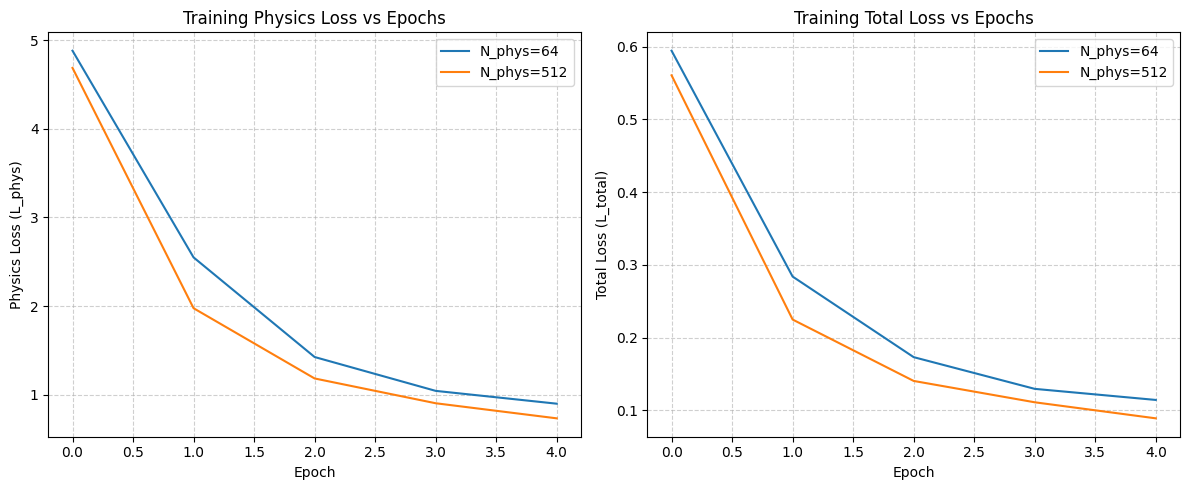

In [28]:
# Plot Physics Loss and Total Loss vs Epochs

plt.figure(figsize=(12, 5))

# Physics Loss over epochs (training)
plt.subplot(1, 2, 1)
for n, res in results.items():
    plt.plot(res["train"]["phys"], label=f"N_phys={n}")
plt.title("Training Physics Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Physics Loss (L_phys)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)

# Total Loss over epochs (training)
plt.subplot(1, 2, 2)
for n, res in results.items():
    plt.plot(res["train"]["total"], label=f"N_phys={n}")
plt.title("Training Total Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Total Loss (L_total)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


In [ ]:

# ---------------------------------------------------------------------
# Experiment: Effect of Decay Rate on Model Performance
# ---------------------------------------------------------------------

decay_values = [0.0,  0.03, 0.1]   #  decay rates
results_decay = {}

for decay in decay_values:
    print(f"\n🚀 Training with decay_rate = {decay}")
    params = get_hyperparams(num_epochs=50,
                             w_data=1.0,
                             w_phys_init=0.1,
                             decay_rate=decay,
                             N_phys=64,       # keep this fixed for fairness
                             dt=0.01,
                             lr=1e-2)

    # Reinitialize a new model each run
    model_exp = VehicleNN().to(device)
    data_l, phys_l, total_l = train_pinn(model_exp, params, train_loader, device)
    results_decay[decay] = {"data": data_l, "phys": phys_l, "total": total_l}


In [ ]:
#Decay rate visulaization
plt.figure(figsize=(12,5))

# --- Physics Loss ---
plt.subplot(1,2,1)
for decay, res in results_decay.items():
    plt.plot(res["phys"], label=f"decay={decay}")
plt.title("Physics Loss vs Epochs for Different Decay Rates")
plt.xlabel("Epoch")
plt.ylabel("L_phys")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# --- Total Loss ---
plt.subplot(1,2,2)
for decay, res in results_decay.items():
    plt.plot(res["total"], label=f"decay={decay}")
plt.title("Total Loss vs Epochs for Different Decay Rates")
plt.xlabel("Epoch")
plt.ylabel("L_total")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


In [57]:
 # mse erorr and r2 score evaution for Validation data(20%)


import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

model.eval()
with torch.no_grad():
    X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
    Y_test_t = torch.tensor(Y_test_scaled, dtype=torch.float32).to(device)

    # NN prediction (scaled output)
    Y_pred_scaled = model(X_test_t)

    #  Convert predictions to real physical units (m/s)
    scale_tensor = torch.tensor(scaler_Y.scale_, dtype=torch.float32, device=device)
    mean_tensor  = torch.tensor(scaler_Y.mean_, dtype=torch.float32, device=device)
    Y_pred_real = (Y_pred_scaled * scale_tensor + mean_tensor).cpu().numpy()


    Y_true_real = scaler_Y.inverse_transform(Y_test_scaled)

# Compute metrics
mse_vx = mean_squared_error(Y_true_real[:,0], Y_pred_real[:,0])
mse_vy = mean_squared_error(Y_true_real[:,1], Y_pred_real[:,1])
r2_vx  = r2_score(Y_true_real[:,0], Y_pred_real[:,0])
r2_vy  = r2_score(Y_true_real[:,1], Y_pred_real[:,1])

print(" Validation Data Evaluation Results:")
print(f"MSE(vx): {mse_vx:.6f} | R²(vx): {r2_vx:.4f}")
print(f"MSE(vy): {mse_vy:.6f} | R²(vy): {r2_vy:.4f}")


 Validation Data Evaluation Results:
MSE(vx): 0.015680 | R²(vx): 0.9999
MSE(vy): 0.000006 | R²(vy): 0.9999


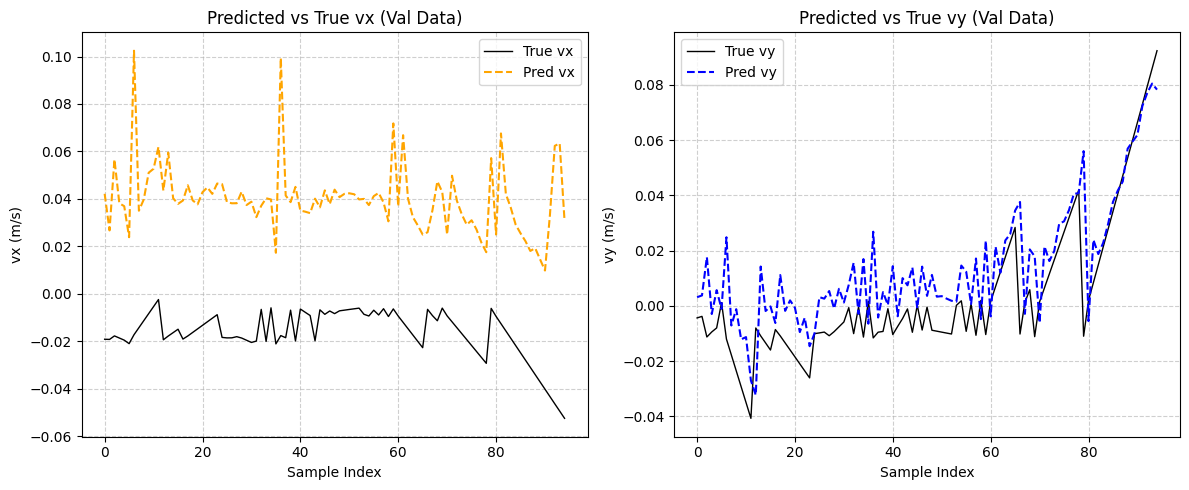

In [72]:

# Prediction vs True Vx,Vy COmparison Plot for Validation data


plt.figure(figsize=(12,5))

#  vx
plt.subplot(1,2,1)
plt.plot(y_true_v[:300,0], label='True vx', color='black', linewidth=1)
plt.plot(y_pred_v[:300,0], '--', label='Pred vx', color='orange')
plt.title("Predicted vs True vx (Val Data)")
plt.xlabel("Sample Index")
plt.ylabel("vx (m/s)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

#  vy 
plt.subplot(1,2,2)
plt.plot(y_true_v[:300,1], label='True vy', color='black', linewidth=1)
plt.plot(y_pred_v[:300,1], '--', label='Pred vy', color='blue')
plt.title("Predicted vs True vy (Val Data)")
plt.xlabel("Sample Index")
plt.ylabel("vy (m/s)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


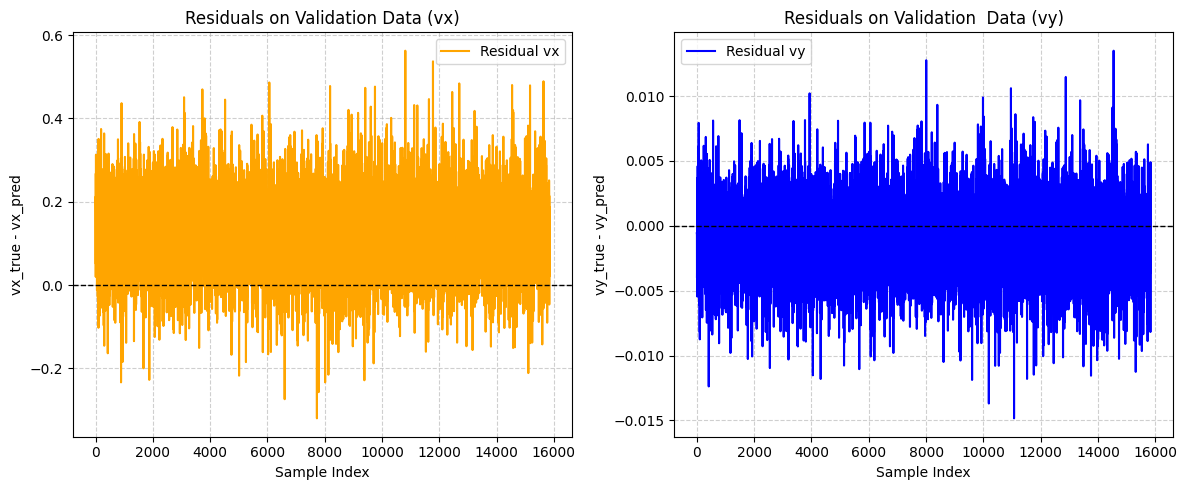

Residual stats (Validation Data):
vx → mean: 0.1007, std: 0.0744, RMSE: 0.1252
vy → mean: -0.0009, std: 0.0023, RMSE: 0.0025


In [ ]:
# Residual Plot for validation data

res_vx = Y_true_real[:,0] - Y_pred_real[:,0]
res_vy = Y_true_real[:,1] - Y_pred_real[:,1]

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(res_vx, label='Residual vx', color='orange')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title("Residuals on Validation Data (vx)")
plt.xlabel("Sample Index")
plt.ylabel("vx_true - vx_pred")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1,2,2)
plt.plot(res_vy, label='Residual vy', color='blue')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title("Residuals on Validation  Data (vy)")
plt.xlabel("Sample Index")
plt.ylabel("vy_true - vy_pred")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

#  Residual stats 
print("Residual stats (Validation Data):")
print(f"vx → mean: {np.mean(res_vx):.4f}, std: {np.std(res_vx):.4f}, RMSE: {np.sqrt(np.mean(res_vx**2)):.4f}")
print(f"vy → mean: {np.mean(res_vy):.4f}, std: {np.std(res_vy):.4f}, RMSE: {np.sqrt(np.mean(res_vy**2)):.4f}")


# Hyper Parameter Tuning Using Raytune



In [29]:

## Import ray and MLFLOW lib

from ray import tune
from ray.tune.search.bayesopt import BayesOptSearch
from ray.tune.schedulers import ASHAScheduler
from ray.air.integrations.mlflow import MLflowLoggerCallback
from ray.air import session
import mlflow, ray, numpy as np
from ray.tune.search.hyperopt import HyperOptSearch
from ray.tune.search.optuna import OptunaSearch
from ray.tune.search.basic_variant import BasicVariantGenerator

## Initialize Ray

In [30]:
# Initialize Ray

ray.shutdown()
ray.init(ignore_reinit_error=True, log_to_driver=False)

2025-11-24 22:23:38,919	INFO worker.py:2012 -- Started a local Ray instance.
c:\Users\msbka\anaconda3\envs\oopEnv\lib\site-packages\ray\_private\worker.py:2051: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


Python version:,3.10.16
Ray version:,2.51.1


In [32]:
# MLflow tracking director and new Experiment for Hyperopt algorithm

mlflow.set_tracking_uri("http://127.0.0.1:5000")        
mlflow.set_experiment("PINN_Tuning_HyperOpti_valdata_ASHA")

2025/11/24 22:24:15 INFO mlflow.tracking.fluent: Experiment with name 'PINN_Tuning_HyperOpti_valdata_ASHA' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:///C:/Users/msbka/mlruns/7', creation_time=1764019455594, experiment_id='7', last_update_time=1764019455594, lifecycle_stage='active', name='PINN_Tuning_HyperOpti_valdata_ASHA', tags={}>

In [33]:
# MLflow tracking director and new Experiment for Optuna algorithm

mlflow.set_tracking_uri("http://127.0.0.1:5000")        
mlflow.set_experiment("PINN_Tuning_Optuna_ASHA")

<Experiment: artifact_location='file:///C:/Users/msbka/mlruns/3', creation_time=1763634981953, experiment_id='3', last_update_time=1763634981953, lifecycle_stage='active', name='PINN_Tuning_Optuna_ASHA', tags={}>

In [52]:
# MLflow tracking director and new Experiment for Random Search algorithm

mlflow.set_tracking_uri("http://127.0.0.1:5000")        
mlflow.set_experiment("PINN_Tuning_Random_ASHA")

<Experiment: artifact_location='file:///C:/Users/msbka/mlruns/5', creation_time=1763675647245, experiment_id='5', last_update_time=1763675647245, lifecycle_stage='active', name='PINN_Tuning_Random_ASHA', tags={'mlflow.experimentKind': 'custom_model_development'}>

## Hyperparameter Search space and Algorithm Intialization (RayTune)

In [33]:

# ---------------------------------------------------------------------
# Hyperparameter search space
# ---------------------------------------------------------------------


search_space = {
    "lr":          tune.loguniform(5e-4, 1e-2),
    "w_phys_init": tune.uniform(0.05, 0.5),
    "w_data_init": tune.uniform(0.1, 1.0),
    "decay_rate":  tune.uniform(0.0, 0.1),
    "N_phys":      tune.randint(32, 512),
    "hidden_dim": tune.choice(["32","64","128","256"])
    
}


# ---------------------------------------------------------------------
# Common scheduler (ASHA)
# ---------------------------------------------------------------------
asha_scheduler = ASHAScheduler(
    max_t=35,
    grace_period=5,
    reduction_factor=2,
)


# ---------------------------------------------------------------------
# 1) Bayesian Optimization (BayesOpt + ASHA + MLflow)
# ---------------------------------------------------------------------


bayes = BayesOptSearch(metric="val_total", mode="min", random_search_steps=6)
mlf_cb = MLflowLoggerCallback(
    tracking_uri=mlflow.get_tracking_uri(),
    experiment_name="PINN_Tuning_BayesOpt_ASHA"
)


# ---------------------------------------------------------------------
# 2) HyperOpt (TPE) + ASHA + MLflow
# ---------------------------------------------------------------------

hyperopt=HyperOptSearch(metric="val_total",mode="min")
mlf_2 = MLflowLoggerCallback(
    tracking_uri=mlflow.get_tracking_uri(),
    experiment_name="PINN_Tuning_HyperOpti_val_ASHA"
)


# ---------------------------------------------------------------------
# 3) Optuna + ASHA + MLflow
# ---------------------------------------------------------------------

Optuna=OptunaSearch(metric="val_total",mode="min")
mlf_3 = MLflowLoggerCallback(
    tracking_uri=mlflow.get_tracking_uri(),
    experiment_name="PINN_Tuning_Optuna_ASHA"
)

# ---------------------------------------------------------------------
# 3) RandomSearch + ASHA + MLflow
# ---------------------------------------------------------------------
random_search = BasicVariantGenerator()
mlf_r = MLflowLoggerCallback(
    tracking_uri=mlflow.get_tracking_uri(),
    experiment_name="PINN_Tuning_Random_ASHA"
)



## Model Training and MLflow Tracking

Ray Tune trainable for the Physics-Informed Neural Network (PINN).

Workflow:
1. Build a hyperparameter dictionary from Ray's `config`.
2. Initialize a fresh VehicleNN model for this trial.
3. Train on Car A data (train_loader) for `num_epochs`.
         - Compute data loss (MSE) on batches.
         - Compute physics loss using random collocation points.
         - Combine them with a decayed physics weight w_phys.
4. After training, evaluate on Car B (test_loader_carB) using
         `evaluate_pinn_on_test`.
5. Report final metrics to Ray Tune (and MLflow via callback).
6. Log the trained model to MLflow as an artifact.

Ray / MLflow:
- Hyperparameters are taken from `config` and can be logged by
    MLflowLoggerCallback automatically.
- Metrics are reported via `session.report(metrics)`.
- The trained model is stored using `mlflow.pytorch.log_model`.



In [34]:
def trainable_pinn_ray(config):
   
    # ------------------------------------------------------------------
    # 1. Construct hyperparameter dictionary from Ray's config
    # ------------------------------------------------------------------

    params = get_hyperparams(
        num_epochs   = 50,                             # fixed in this experiment
        w_data       = float(config["w_data_init"]),
        w_phys_init  = float(config["w_phys_init"]),
        decay_rate   = float(config["decay_rate"]),
        N_phys       = int(config["N_phys"]),
        dt           = 0.01,
        lr           = float(config["lr"])
    )

     # ------------------------------------------------------------------
    # 2. Initialize a new model for this Ray trial
    # ------------------------------------------------------------------

    model_trial = VehicleNN(hidden_dim=int(config["hidden_dim"])).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=params["lr"])
    criterion = RMSELoss()



    # ------------------------------------------------------------------
    # 3. Training loop on Car A (train_loader)
    # ------------------------------------------------------------------

    for epoch in range(params["num_epochs"]):
        model.train()
        total_loss_data, total_loss_phys, total_loss = 0.0, 0.0, 0.0

        # Exponential decay for physics weight
        w_phys = params["w_phys_init"] * math.exp(-params["decay_rate"] * epoch)

        for Xb, Yb in train_loader:   # <--- Car A
            Xb, Yb = Xb.to(device), Yb.to(device)
            optimizer.zero_grad()

            # NN data loss 
            Y_pred = model(Xb)
            loss_data = criterion(Y_pred, Yb)

            # Physics loss (random points)
            loss_phys = compute_physics_loss_torch(model, params["N_phys"], params["dt"], device)

            loss_total = params["w_data"] * loss_data + w_phys * loss_phys

            loss_total.backward()
            optimizer.step()

            total_loss_data += loss_data.item()
            total_loss_phys += loss_phys.item()
            total_loss += loss_total.item()

        # Average over batches
        avg_data_loss = total_loss_data / len(train_loader)
        avg_phys_loss = total_loss_phys / len(train_loader)
        avg_total_loss = total_loss / len(train_loader)

        # ------------------------------------------------------------------
        # 4. Evaluate on Car a Val data after this epoch
        # ------------------------------------------------------------------

        model.eval()
        with torch.no_grad():
            data_loss_b, phys_loss_b, total_loss_b,y_true_v,y_pred_v = evaluate_pinn_on_test(
                model, Val_Data_loader, device, dt=params["dt"], N_phys=params["N_phys"],w_data=params["w_data"],w_phys_init=params["w_phys_init"],decay_rate=params["decay_rate"],
        epoch_idx=params["num_epochs"]-1
            )

        # ------------------------------------------------------------------
        # 5. Report metrics to Ray / MLflow
        # ------------------------------------------------------------------

    metrics = {
            "epoch": epoch + 1,
            "train_data": avg_data_loss,
            "train_phys": avg_phys_loss,
            "train_total": avg_total_loss,
            "val_data": data_loss_b,        
            "val_phys": phys_loss_b,        
            "val_total": total_loss_b       
    }


    # This sends metrics to Ray Tune. The MLflowLoggerCallback records
    # them automatically in MLflow as a "trace" per trial.
    session.report(metrics)

    # ----------------------------------------------------------------------
    # 6. Log the final trained model for this trial as an MLflow artifact
    # ----------------------------------------------------------------------
   
    # log params, metrics, model, artifacts
        
    mlflow.log_params({
        "lr": params["lr"],
        "N_phys": params["N_phys"],
        "decay_rate": params["decay_rate"],
        "w_data": params["w_data"],
        "w_phys_init": params["w_phys_init"]
    })

    for epoch in range(num_epochs):
        ...
        mlflow.log_metric("train_total_loss", avg_total_loss, step=epoch)
        mlflow.log_metric("train_data_loss", avg_data_loss, step=epoch)
        mlflow.log_metric("train_phys_loss", avg_phys_loss, step=epoch)

    
    mlflow.pytorch.log_model(model_trial, artifact_path="model")



In [ ]:
# # Hyperparameter Optimization using Ray Tune with BaysianOpt + ASHA + MLflow


# ## commented this because of bayesian not taking catagorical Data ( Tune.choice or tune.randint) error. and using Other optimizers.


# tuner = tune.Tuner(
# tune.with_resources(trainable_pinn_ray, {"cpu": 2, "gpu": 0}),
# tune_config=tune.TuneConfig(
#     metric="val_total",
#     mode="min",
#     num_samples=2,
#     search_alg=bayes,
#     scheduler=asha_scheduler
# ),
# run_config=ray.air.RunConfig(
#     name="PINN_Tuning_Bayesian_ASHA",
#     callbacks=[mlf_cb]
# ),
# param_space=search_space
# )

# results = tuner.fit()

# best = results.get_best_result(metric="val_total", mode="min")
# print("\n Best configuration found:")
# print(best.config)
# print(f"Best Total Loss: {best.metrics['val_total']:.6f}")


In [ ]:

# Hyperparameter Optimization using Ray Tune with HyperOpt + ASHA + MLflow

tuner = tune.Tuner(
    tune.with_resources(trainable_pinn_ray, {"cpu": 2, "gpu": 0}),
    tune_config=tune.TuneConfig(
        metric="val_total",
        mode="min",
        num_samples=300,
        search_alg=hyperopt,
        scheduler=asha_scheduler
    ),
    run_config=ray.air.RunConfig(
        name="PINN_Tuning_HyperOpti_val_ASHA",
        callbacks=[mlf_2]
    ),
    param_space=search_space
)

results = tuner.fit()


# Retrieve best result
best = results.get_best_result(metric="val_total", mode="min")
print("\n Best configuration found from hyperopt:")
print(best.config)
print(f"Best Total Loss: {best.metrics['val_total']:.6f}")

In [ ]:

# Hyperparameter Optimization using Ray Tune with Optuna + ASHA + MLflow


tuner = tune.Tuner(
    tune.with_resources(trainable_pinn_ray, {"cpu": 2, "gpu": 0}),
    tune_config=tune.TuneConfig(
        metric="val_total",
        mode="min",
        num_samples=100,
        search_alg=Optuna,
        scheduler=asha_scheduler
    ),
    run_config=ray.air.RunConfig(
        name="PINN_Tuning_Optuna_ASHA",
        callbacks=[mlf_3]
    ),
    param_space=search_space
)

results = tuner.fit()

best = results.get_best_result(metric="val_total", mode="min")
print("\n Best configuration found from optuna:")
print(best.config)
print(f"Best Total Loss: {best.metrics['val_total']:.6f}")

In [ ]:

# Hyperparameter Optimization using Ray Tune with Optuna + ASHA + MLflow


tuner = tune.Tuner(
    tune.with_resources(trainable_pinn_ray, {"cpu": 2, "gpu": 0}),
    tune_config=tune.TuneConfig(
        metric="val_total",
        mode="min",
        num_samples=300,
        search_alg=random_search,
        scheduler=asha_scheduler
    ),
    run_config=ray.air.RunConfig(
        name="PINN_Tuning_Random_ASHA",
        callbacks=[mlf_r]
    ),
    param_space=search_space
)

results = tuner.fit()

best = results.get_best_result(metric="val_total", mode="min")
print("\n Best configuration found from optuna:")
print(best.config)
print(f"Best Total Loss: {best.metrics['val_total']:.6f}")

# SHapley Additive exPlanations.

How much that feature's value contributed to the difference between the actual prediction and the average prediction of the dataset.

Feature Importance Plot
Provides a clear, aggregated rank of feature influence, without showing the direction (positive/negative) of the impact.

SHAP Summary Plot

Indicates the feature's contribution for a single data point. The grey vertical line is the base value (average model output). Dots to the right increase the model output (e.g., higher loss); dots to the left decrease the output (e.g., lower loss).

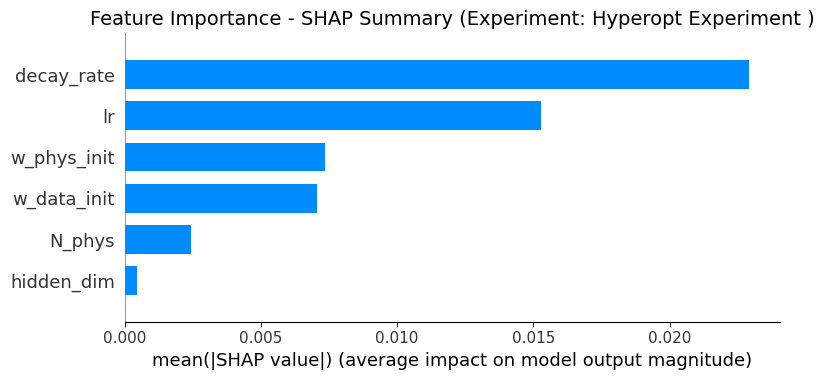

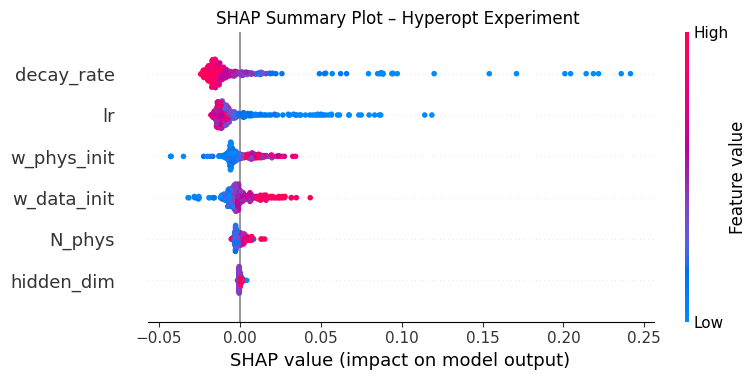

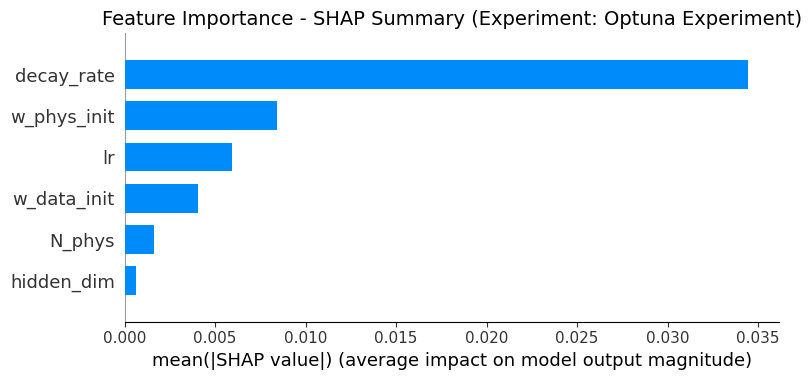

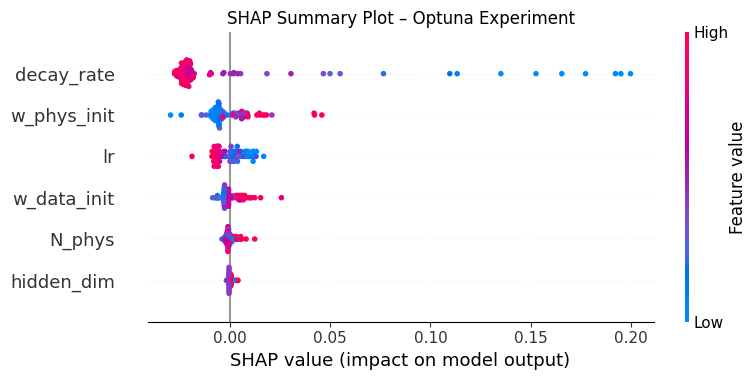

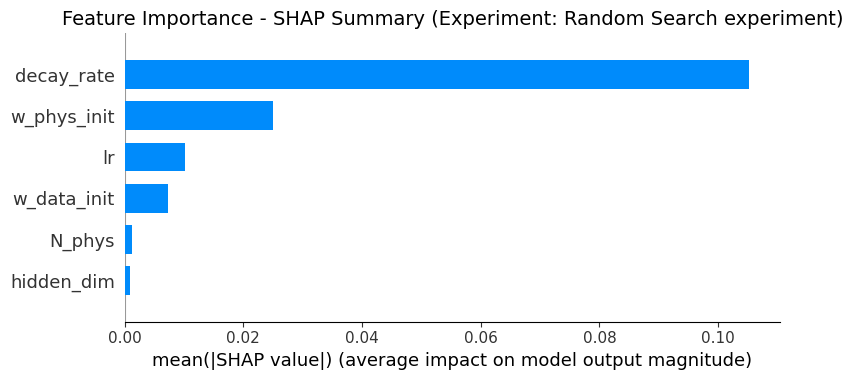

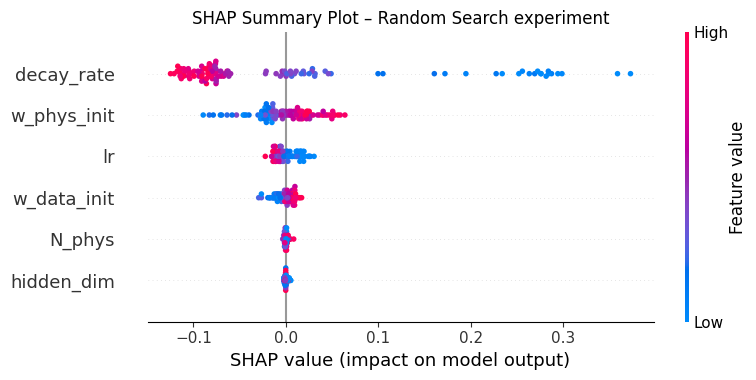

In [46]:
import pandas as pd
import shap
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# ============= Step 1: Load your 3 experiment datasets =============
# Load your experiment results
df_exp1 = pd.read_csv(r"C:\Users\msbka\Downloads\HyperoptResults.csv")
df_exp2 = pd.read_csv(r"C:\Users\msbka\Downloads\OptunaResults.csv")
df_exp3 = pd.read_csv(r"C:\Users\msbka\Downloads\RandomSearchResults.csv")

datasets = [
    ("Experiment 1", df_exp1),
    ("Experiment 2", df_exp2),
    ("Experiment 3", df_exp3)
]

# ============= Step 2: Define reusable cleaning + SHAP function =============
def shap_plot_for_experiment(df, exp_name):
    """
    Generate SHAP feature importance visualization for a given experiment.
    """
    # Select only hyperparameter columns
    config_cols = [c for c in df.columns if c.startswith("config/")]
    
    # Prepare features and target
    X = df[config_cols].copy()
    X.columns = [c.replace("config/", "") for c in config_cols]
    X = X.apply(pd.to_numeric, errors="coerce")

    y = pd.to_numeric(df["val_total"], errors="coerce")

    # Drop NaN or infinite values
    mask = (~X.isna().any(axis=1)) & (~y.isna())
    X = X[mask]
    y = y[mask]

    if len(X) < 5:
        print(f"⚠ Not enough valid samples for SHAP in {exp_name} (only {len(X)} rows)")
        return

    # Train surrogate model
    model = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
    model.fit(X, y)

    # Compute SHAP values
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)

    # 🔹 Plot Setup: Larger, properly aligned, titled
    plt.figure(figsize=(10, 5))
    plt.title(f"Feature Importance - SHAP Summary (Experiment: {exp_name})", fontsize=14)
    shap.summary_plot(shap_values, X, plot_type="bar", show=False)
    plt.tight_layout()
    plt.show()

    # --- Plot 2: SHAP Beeswarm Summary Plot ---
    plt.figure(figsize=(8, 4))
    shap.summary_plot(shap_values, X, show=False)
    plt.title(f"SHAP Summary Plot – {exp_name}")
    plt.tight_layout()
    plt.show()


# ============= Step 5: Run for all datasets =============
# Run SHAP plots for each experiment

shap_plot_for_experiment(df_exp1, "Hyperopt Experiment ")
shap_plot_for_experiment(df_exp2, "Optuna Experiment")
shap_plot_for_experiment(df_exp3, "Random Search experiment")


# Validating Final loss with Test data Using Best Parameter

In [30]:
def as_float(value):
    return value[0] if isinstance(value, list) else value


In [33]:
import pandas as pd
import torch

csv_files = {
    #"Random Search": (r"C:\Users\msbka\Downloads\RandomSearchResults.csv"),
    "HyperOpt": (r"C:\Users\msbka\Downloads\runs (3).csv"),
    #"Optuna":  (r"C:\Users\msbka\Downloads\OptunaResults.csv")
}

results_summary = {}

def extract_best_params(df):
    best_row = df.loc[df["val_total"].idxmin()]
    params = {
        "num_epochs": 50,
        "lr": float(best_row["config/lr"]),
        "hidden_dim": int(best_row["config/hidden_dim"]),
        "N_phys": int(best_row["config/N_phys"]),
        "w_data": float(best_row["config/w_data_init"]),
        "w_phys_init": float(best_row["config/w_phys_init"]),
        "decay_rate": float(best_row["config/decay_rate"]),
        "dt": 0.01
    }
    return params

for exp_name, file in csv_files.items():

    print(f"\n Processing {exp_name} results...")
    df = pd.read_csv(file)

    best_params = extract_best_params(df)
    print("Best Parameters:", best_params)

#     # Initialize model with best hidden_dim
#     model = VehicleNN(hidden_dim=best_params["hidden_dim"]).to(device)

#     data_l, phys_l, total_l = train_pinn(
#     model,
#     best_params,
#     train_loader,
#     device
# )   

    # Evaluate on test data
    data_test, phys_test, total_test ,Y_true_real, Y_pred_real = evaluate_pinn_on_test(
        model,
        test_loader_carB,
        device,
        dt=best_params["dt"],
        N_phys=best_params["N_phys"],
        w_data=best_params["w_data"],
        w_phys_init=best_params["w_phys_init"],
        decay_rate=best_params["decay_rate"],
        epoch_idx=best_params["num_epochs"] - 1
    )

    # Store results
    results_summary[exp_name] = {
        
        "test_loss": total_test,
        "data_loss": data_test,
        "phys_loss": phys_test,
        "params": best_params,
        "Y_true": Y_true_real,
        "Y_pred": Y_pred_real
    }

print("\n=====  Final Comparison Across Optimizers =====")
for exp, res in results_summary.items():
    print(f"\n🔹 {exp}")
    print(f"  Best Params: {res['params']}")
    print(f"  Test Total Loss:  {as_float(res['test_loss']):.6f}")
    print(f"  Data Loss:        {as_float(res['data_loss']):.6f}")
    print(f"  Physics Loss:     {as_float(res['phys_loss']):.6f}")


 Processing HyperOpt results...
Best Parameters: {'num_epochs': 50, 'lr': 0.0023264934775313, 'hidden_dim': 64, 'N_phys': 143, 'w_data': 0.1208792133023471, 'w_phys_init': 0.0612223940732157, 'decay_rate': 0.0981792232406304, 'dt': 0.01}

 Evaluation on :
   NN (data) loss:   0.002068
   Physics loss:     5.603710
   Total loss:       0.343323   (w_data=0.1208792133023471, w_phys=0.0612223940732157)

=====  Final Comparison Across Optimizers =====

🔹 HyperOpt
  Best Params: {'num_epochs': 50, 'lr': 0.0023264934775313, 'hidden_dim': 64, 'N_phys': 143, 'w_data': 0.1208792133023471, 'w_phys_init': 0.0612223940732157, 'decay_rate': 0.0981792232406304, 'dt': 0.01}
  Test Total Loss:  0.343323
  Data Loss:        0.002068
  Physics Loss:     5.603710


In [34]:
# Final: Print clean results for each experiment
print("\n" + "="*80)
print(" FINAL EVALUATION SUMMARY")
print("="*80)

for exp, res in results_summary.items():  # make sure all_results is your final results dict
    print(f"\n🔹 Experiment: {exp}")

    print(" Best Parameters:")
    for k, v in res['params'].items():
        print(f"   {k}: {v}")

    print("\nEvaluation Metrics:")
    print(f"   Test Total Loss:  {as_float(res['test_loss']):.6f}")
    print(f"   Data Loss:        {as_float(res['data_loss']):.6f}")
    print(f"   Physics Loss:     {as_float(res['phys_loss']):.6f}")

    if 'rmse_vx' in res:
        print(f"   RMSE vx:          {res['rmse_vx']:.6f}")
        print(f"   RMSE vy:          {res['rmse_vy']:.6f}")

print("\n" + "="*80)
print("✔ End of Evaluation Summary")
print("="*80)



 FINAL EVALUATION SUMMARY

🔹 Experiment: HyperOpt
 Best Parameters:
   num_epochs: 50
   lr: 0.0023264934775313
   hidden_dim: 64
   N_phys: 143
   w_data: 0.1208792133023471
   w_phys_init: 0.0612223940732157
   decay_rate: 0.0981792232406304
   dt: 0.01

Evaluation Metrics:
   Test Total Loss:  0.343323
   Data Loss:        0.002068
   Physics Loss:     5.603710

✔ End of Evaluation Summary


In [40]:
import pandas as pd

# Print first few rows of Actual vs Predicted values for each experiment
for exp, res in results_summary.items():
    print(f"\n🔹 {exp} – First few rows of Actual vs Predicted values:")
    
    # Extract arrays
    Y_true = res["Y_true"]
    Y_pred = res["Y_pred"]

    # Convert to DataFrame for better viewing
    df_preview = pd.DataFrame({
        "True_Vx": Y_true[:10, 0],
        "Pred_Vx": Y_pred[:10, 0],
        "True_Vy": Y_true[:10, 1],
        "Pred_Vy": Y_pred[:10, 1]
    })

    print(df_preview.to_string(index=False))



🔹 HyperOpt – First few rows of Actual vs Predicted values:
  True_Vx   Pred_Vx   True_Vy   Pred_Vy
-0.008259 -0.080736 -0.010671 -0.009223
-0.007801 -0.052309 -0.011620 -0.006780
-0.009636 -0.079971 -0.007932 -0.011131
-0.009081 -0.065683 -0.008742 -0.004430
-0.008402 -0.086943 -0.009599 -0.006951
-0.007725 -0.054663 -0.010456 -0.005878
-0.010090  0.013786 -0.006974 -0.012074
-0.009413 -0.011053 -0.008067 -0.001531
-0.009573 -0.077284 -0.007226 -0.005169
-0.009729 -0.063963 -0.006386 -0.004034



🔹 HyperOpt – RMSE Results
   RMSE (Vx): 0.026354
   RMSE (Vy): 0.007140


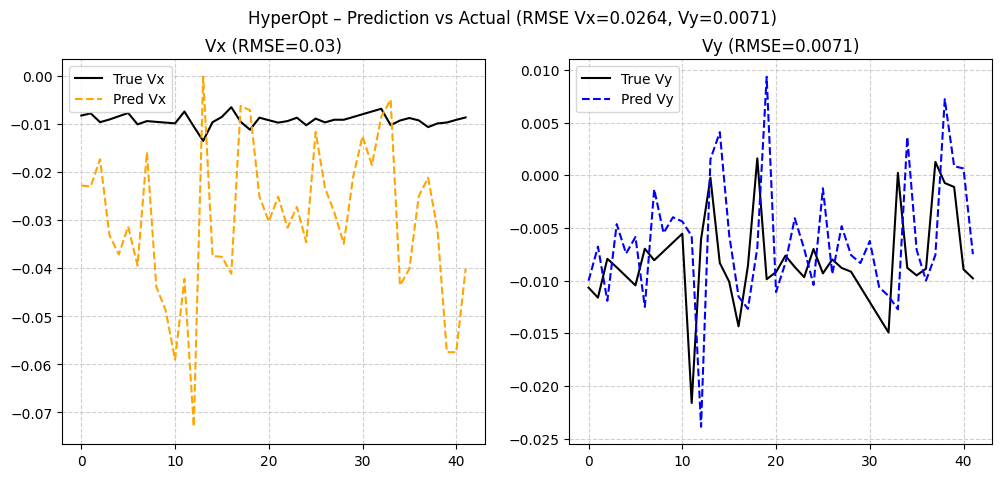

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

for exp, res in results_summary.items():
    Y_true = res["Y_true"]
    Y_pred = res["Y_pred"]

    

    # === RMSE Calculation for vx and vy ===
    rmse_vx = np.sqrt(mean_squared_error(Y_true[:, 0], Y_pred[:, 0]))
    rmse_vy = np.sqrt(mean_squared_error(Y_true[:, 1], Y_pred[:, 1]))

    print(f"\n🔹 {exp} – RMSE Results")
    print(f"   RMSE (Vx): {rmse_vx:.6f}")
    print(f"   RMSE (Vy): {rmse_vy:.6f}")

    # === Prediction vs Actual Plot ===
    plt.figure(figsize=(12,5))
    plt.suptitle(f"{exp} – Prediction vs Actual (RMSE Vx={rmse_vx:.4f}, Vy={rmse_vy:.4f})")

    # Vx plot
    plt.subplot(1,2,1)
    plt.plot(Y_true[:300,0], label='True Vx', color='black')
    plt.plot(Y_pred[:300,0], '--', label='Pred Vx', color='orange')
    plt.title(f"Vx (RMSE={rmse_vx:.2f})")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    # Vy plot
    plt.subplot(1,2,2)
    plt.plot(Y_true[:300,1], label='True Vy', color='black')
    plt.plot(Y_pred[:300,1], '--', label='Pred Vy', color='blue')
    plt.title(f"Vy (RMSE={rmse_vy:.4f})")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    plt.show()



 FINAL EVALUATION SUMMARY

🔹 Experiment: Random Search
 Best Parameters:
   num_epochs: 50
   lr: 0.0015877537025178
   hidden_dim: 256
   N_phys: 380
   w_data: 0.1134655080348101
   w_phys_init: 0.0507320930207505
   decay_rate: 0.0845248806539676
   dt: 0.01

Evaluation Metrics:
   Test Total Loss:  0.005023
   Data Loss:        0.030389
   Physics Loss:     1.953064

🔹 Experiment: HyperOpt
 Best Parameters:
   num_epochs: 50
   lr: 0.0060737977680008
   hidden_dim: 128
   N_phys: 185
   w_data: 0.3821411871221107
   w_phys_init: 0.0501786891453682
   decay_rate: 0.0999465412817706
   dt: 0.01

Evaluation Metrics:
   Test Total Loss:  0.002821
   Data Loss:        0.004731
   Physics Loss:     2.705021

🔹 Experiment: Optuna
 Best Parameters:
   num_epochs: 50
   lr: 0.0084737044667228
   hidden_dim: 128
   N_phys: 345
   w_data: 0.544546652603305
   w_phys_init: 0.0510477907065644
   decay_rate: 0.0961596993295946
   dt: 0.01

Evaluation Metrics:
   Test Total Loss:  0.003915
   Da